# Smart Fund Advisor — Notebook 1: EDA & Feature Engineering

**Objective:**  
Explore the bank user dataset (50 k rows × 27 cols) and mutual fund catalogue (16 k rows × 16 cols),  
apply EDA-driven data cleaning, plot correlation matrices, identify and remove unnecessary columns,  
then validate the final feature set used for model training.

---

## EDA-Driven Column Removal (Mar 2026)

| Dataset | Columns Removed | Reason |
|---|---|---|
| **Bank** | `ID`, `SSN`, `Name` | PII — no predictive value for risk modelling |
| **Bank** | `Month` | Row-ordering artefact; per-customer aggregation already captures temporal change |
| **Bank** | `Type_of_Loan` | Free-text label, 11.4 % null; `Num_of_Loan` captures the count |
| **Bank** | `Credit_History_Age` | Replaced by pre-computed `Credit_History_Months` (integer, parsed) |
| **Fund** | `ISIN_Div_Payout/Growth`, `ISIN_Div_Reinvestment`, `ISIN_Div_Payout/Growth/Div_Reinvestment` | Identifier codes only — not model features; 12.5 % null |
| **Fund** | `AAUM_Quarter` | Quarter-label duplicate of `Average_AUM_Cr`; 51 % null |

**Correlation finding:** Zero highly-correlated pairs (|r| > 0.80) detected across all 21 bank numeric features  
→ no additional feature removal triggered on correlation grounds.

**Resulting clean datasets (used by all downstream models):**
- `Data/bank_user_dataset_clean.csv` — 50 000 rows × 22 cols  
- `Data/mutual_fund_data_clean.csv` — 16 376 rows × 12 cols

In [1]:
# ── 0. Bootstrap path so notebooks can import from src/ ──
import sys, os
sys.path.insert(0, os.path.abspath('..'))
#os.chdir('..')   # make cwd the project root

# Purge any stale src module cache so changes to src/ are picked up fresh
for _mod in list(sys.modules.keys()):
    if _mod.startswith('src') or _mod == 'config':
        del sys.modules[_mod]

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
# matplotlib.use('inline')
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# ── Shared save directory (works regardless of cwd) ──
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)

print('Libraries loaded ✓')
print(f'Plot save dir : {save_dir}')


Libraries loaded ✓
Plot save dir : /Users/chaitanya/Downloads/Submission/Code/20Feb26/models


---
## 0b. Raw Dataset Inspection & EDA-Driven Cleaning

In [2]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns, re, os, warnings
warnings.filterwarnings('ignore')

# ── Load RAW datasets for EDA inspection ──
df_bank_raw = pd.read_csv('../Data/bank_user_dataset.csv', low_memory=False)
df_fund_raw = pd.read_csv('../Data/mutual_fund_data.csv',  low_memory=False)

print("─── RAW Bank User Dataset ───────────────────────────────────────")
print(f"  Shape : {df_bank_raw.shape}")
print(f"  Columns ({len(df_bank_raw.columns)}): {list(df_bank_raw.columns)}")
print(f"\n  Missing values (%):")
b_miss = (df_bank_raw.isnull().sum() / len(df_bank_raw) * 100).sort_values(ascending=False)
print(b_miss[b_miss > 0].to_string())

print("\n─── RAW Mutual Fund Dataset ───────────────────────────────────────")
print(f"  Shape : {df_fund_raw.shape}")
print(f"  Columns ({len(df_fund_raw.columns)}): {list(df_fund_raw.columns)}")
print(f"\n  Missing values (%):")
f_miss = (df_fund_raw.isnull().sum() / len(df_fund_raw) * 100).sort_values(ascending=False)
print(f_miss[f_miss > 0].to_string())

─── RAW Bank User Dataset ───────────────────────────────────────
  Shape : (50000, 27)
  Columns (27): ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance']

  Missing values (%):


Monthly_Inhand_Salary      14.996
Type_of_Loan               11.408
Name                       10.030
Credit_History_Age          8.940
Num_of_Delayed_Payment      6.996
Amount_invested_monthly     4.542
Num_Credit_Inquiries        2.070
Monthly_Balance             1.124

─── RAW Mutual Fund Dataset ───────────────────────────────────────
  Shape : (16376, 16)
  Columns (16): ['Scheme_Code', 'Scheme_Name', 'AMC', 'Scheme_Type', 'Scheme_Category', 'Scheme_NAV_Name', 'Scheme_Min_Amt', 'NAV', 'Latest_NAV_Date', 'Average_AUM_Cr', 'AAUM_Quarter', 'ISIN_Div_Payout/Growth', 'ISIN_Div_Reinvestment', 'ISIN_Div_Payout/Growth/Div_Reinvestment', 'Launch_Date', 'Closure_Date']

  Missing values (%):
Closure_Date                               76.398388
Average_AUM_Cr                             50.928188
AAUM_Quarter                               50.928188
NAV                                        12.493894
Latest_NAV_Date                            12.493894
ISIN_Div_Payout/Growth                 

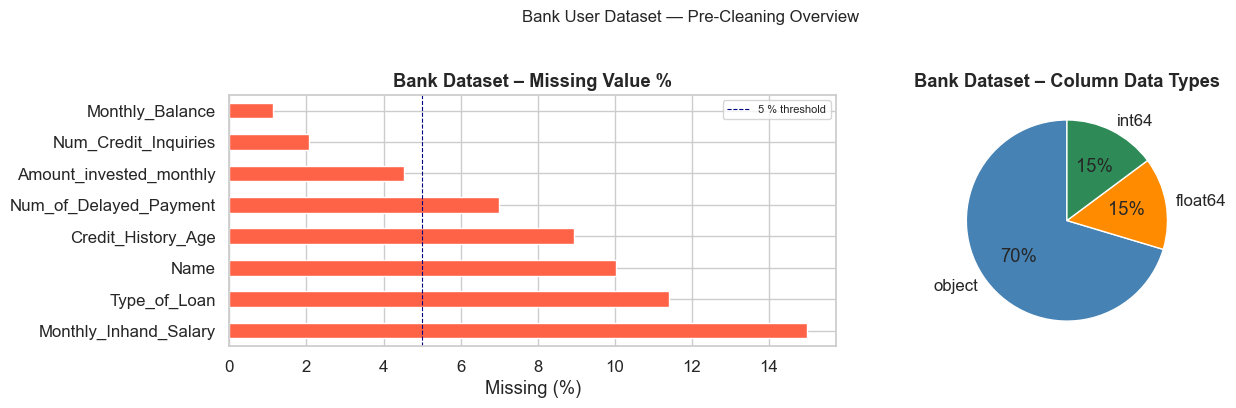

Columns flagged for removal: ['ID', 'SSN', 'Name', 'Month', 'Type_of_Loan', 'Credit_History_Age']


In [3]:
# ── Bank Dataset — Numeric Column Distributions + Missing-value Bar ──────────

bank_null_pct = (df_bank_raw.isnull().sum() / len(df_bank_raw) * 100).sort_values(ascending=False)
bank_null_pct = bank_null_pct[bank_null_pct > 0]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: missing value bar chart
bank_null_pct.plot.barh(ax=axes[0], color='tomato')
axes[0].set_title('Bank Dataset – Missing Value %', fontweight='bold')
axes[0].set_xlabel('Missing (%)')
axes[0].axvline(5, color='navy', linestyle='--', linewidth=0.8, label='5 % threshold')
axes[0].legend(fontsize=8)

# Right: data types breakdown
dtype_counts = df_bank_raw.dtypes.astype(str).value_counts()
axes[1].pie(dtype_counts.values, labels=dtype_counts.index, autopct='%1.0f%%',
            startangle=90, colors=['steelblue','darkorange','seagreen'])
axes[1].set_title('Bank Dataset – Column Data Types', fontweight='bold')

plt.suptitle('Bank User Dataset — Pre-Cleaning Overview', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()
print("Columns flagged for removal:", ['ID','SSN','Name','Month','Type_of_Loan','Credit_History_Age'])

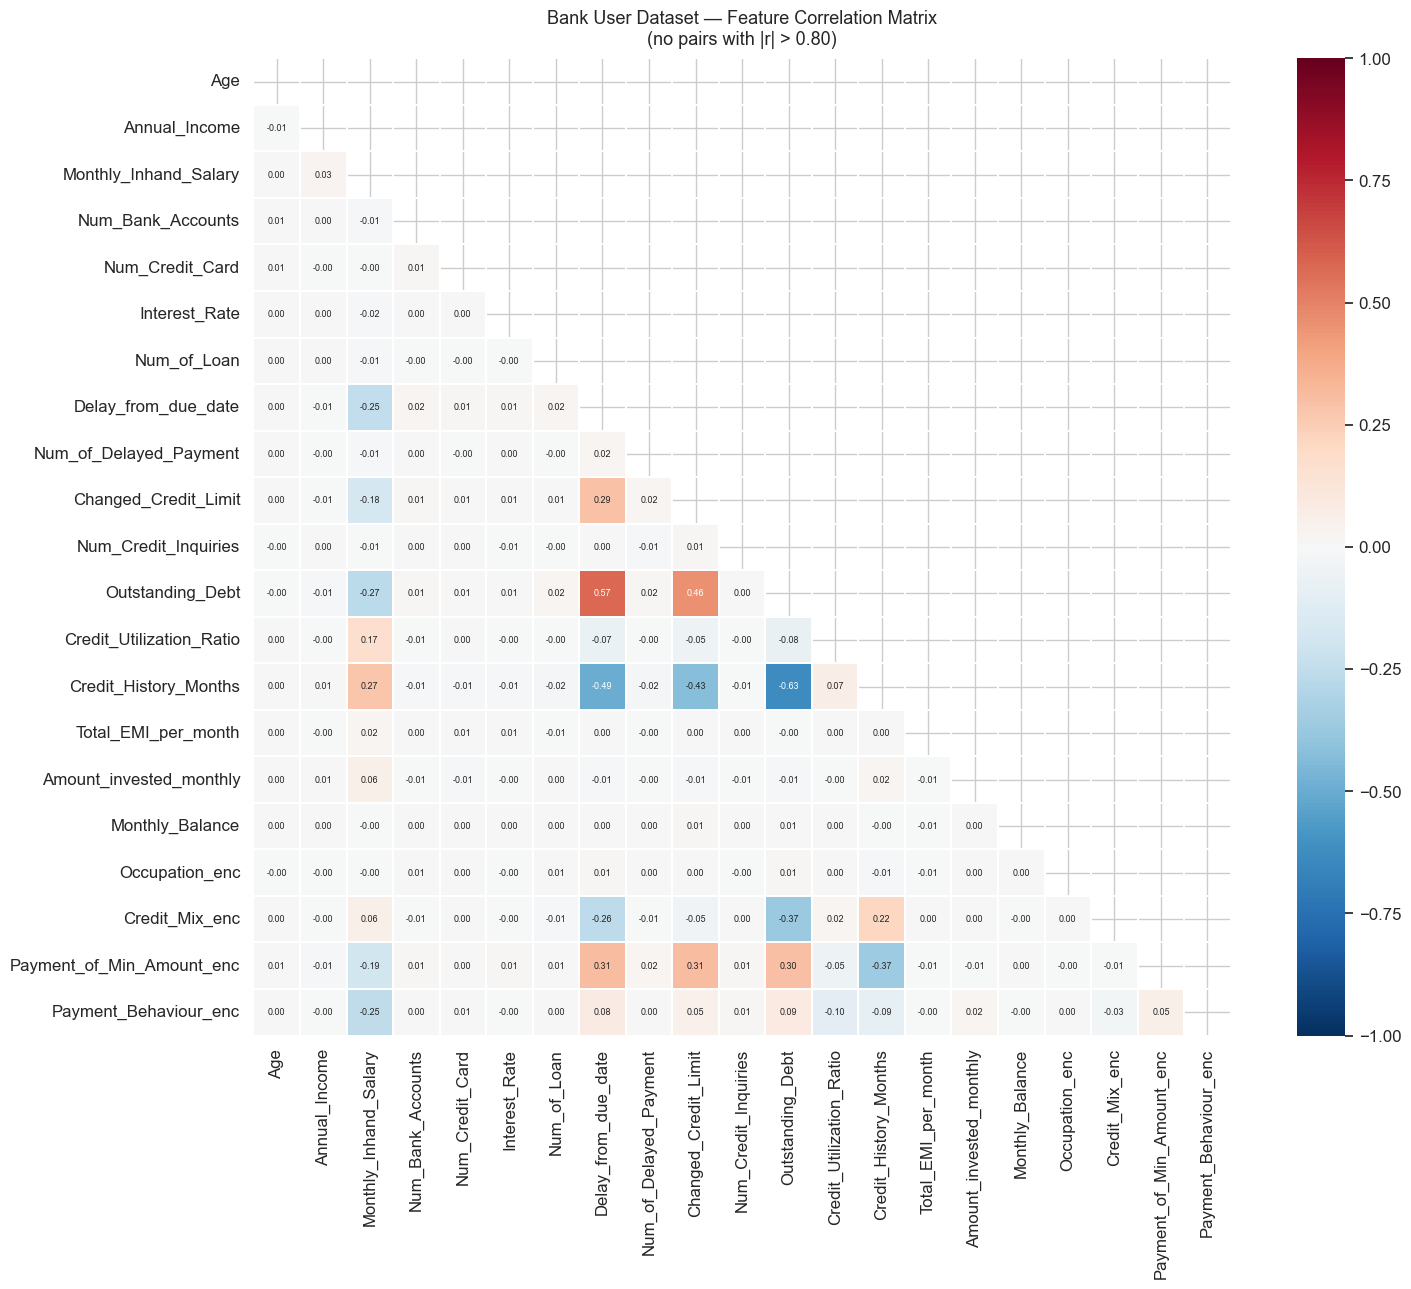

Highly correlated pairs (|r| > 0.80):
  → None found. All features are retained.


In [4]:
# ── Bank Dataset — Correlation Matrix ────────────────────────────────────────
# Clean numeric columns for correlation
def _clean_num(s):
    return pd.to_numeric(
        s.astype(str).str.replace(r'[^\d.\-]','',regex=True),
        errors='coerce')

df_corr = df_bank_raw.copy()
for c in ['Age','Annual_Income','Num_of_Loan','Outstanding_Debt',
          'Monthly_Balance','Amount_invested_monthly','Num_of_Delayed_Payment',
          'Changed_Credit_Limit']:
    df_corr[c] = _clean_num(df_corr[c])

# Credit history months
def _parse_ch(v):
    v = str(v)
    y = re.search(r'(\d+)\s*[Yy]ear', v); m = re.search(r'(\d+)\s*[Mm]onth', v)
    return (int(y.group(1)) if y else 0)*12 + (int(m.group(1)) if m else 0) or np.nan
df_corr['Credit_History_Months'] = df_corr['Credit_History_Age'].apply(_parse_ch)

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in ['Occupation','Credit_Mix','Payment_of_Min_Amount','Payment_Behaviour']:
    df_corr[col+'_enc'] = le.fit_transform(df_corr[col].fillna('Unknown'))

num_cols = [
    'Age','Annual_Income','Monthly_Inhand_Salary','Num_Bank_Accounts',
    'Num_Credit_Card','Interest_Rate','Num_of_Loan','Delay_from_due_date',
    'Num_of_Delayed_Payment','Changed_Credit_Limit','Num_Credit_Inquiries',
    'Outstanding_Debt','Credit_Utilization_Ratio','Credit_History_Months',
    'Total_EMI_per_month','Amount_invested_monthly','Monthly_Balance',
    'Occupation_enc','Credit_Mix_enc','Payment_of_Min_Amount_enc','Payment_Behaviour_enc'
]
num_cols = [c for c in num_cols if c in df_corr.columns]
corr = df_corr[num_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(16, 13))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, ax=ax, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=True, fmt='.2f', annot_kws={'size':6.5},
            linewidths=0.3, square=True)
ax.set_title('Bank User Dataset — Feature Correlation Matrix\n(no pairs with |r| > 0.80)', fontsize=13, pad=10)
plt.tight_layout()
plt.savefig('../eda_outputs/bank_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Print high-correlation pairs
print("Highly correlated pairs (|r| > 0.80):")
found = False
for i in range(len(corr.columns)):
    for j in range(i+1, len(corr.columns)):
        v = corr.iloc[i,j]
        if abs(v) > 0.80:
            print(f"  {corr.columns[i]} ↔ {corr.columns[j]}  r={v:.3f}")
            found = True
if not found:
    print("  → None found. All features are retained.")

In [5]:

# ── 1. Load raw bank dataset + Cleaning Audit ──
import pandas as pd, numpy as np, os
from src.preprocessing import load_and_clean, NON_NEGATIVE_COLS, COLUMN_BOUNDS

RAW_CSV = os.path.join(os.path.abspath('..'), 'Data', 'bank_user_dataset.csv')

# ── Step 0: read raw CSV to quantify issues BEFORE cleaning ──
_raw = pd.read_csv(RAW_CSV)
for c in _raw.columns:
    _raw[c] = pd.to_numeric(_raw[c].astype(str).str.replace(',', ''), errors='coerce')

print("=== BEFORE CLEANING: Range Violations ===")
print(f"{'Column':<28} {'Valid Range':>14}  {'Below Lo':>10}  {'Above Hi':>10}  {'Null':>8}")
print("-" * 75)
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in _raw.columns:
        below = int((_raw[col] < lo).sum())
        above = int((_raw[col] > hi).sum())
        null  = int(_raw[col].isna().sum())
        print(f"  {col:<26} [{lo:>4} – {hi:>4}]  {below:>10}  {above:>10}  {null:>8}")

for col in NON_NEGATIVE_COLS:
    if col in _raw.columns:
        neg  = int((_raw[col] < 0).sum())
        null = int(_raw[col].isna().sum())
        print(f"  {col:<26} [   0 –  inf]  {neg:>10}  {'n/a':>10}  {null:>8}")

# ── Step 1: count how many nulls will be filled per-customer vs global-median ──
print("\n=== NULL-FILL SOURCE (per-customer ffill/bfill vs global-median fallback) ===")
print(f"{'Column':<28} {'Per-Cust Fill':>14}  {'GlobalMed Fill':>14}")
print("-" * 60)
_tmp = _raw.copy()
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in _tmp.columns:
        _tmp[col] = _tmp[col].where(_tmp[col].between(lo, hi), other=np.nan)
for col in NON_NEGATIVE_COLS:
    if col in _tmp.columns:
        _tmp[col] = _tmp[col].clip(lower=0)

for col in _tmp.select_dtypes(include=[np.number]).columns:
    if 'Customer_ID' not in _tmp.columns:
        break
    before_null = int(_tmp[col].isna().sum())
    if before_null == 0:
        continue
    after_pc = _tmp.groupby('Customer_ID')[col].transform(lambda x: x.ffill().bfill())
    per_cust = int(before_null - after_pc.isna().sum())
    global_f = int(after_pc.isna().sum())
    if per_cust + global_f > 0:
        print(f"  {col:<26} {per_cust:>14}  {global_f:>14}")

# ── Step 2: run full clean and validate ──
df_raw = load_and_clean()
print(f"\n=== AFTER CLEANING ===")
print(f"Shape: {df_raw.shape}  |  Unique customers: {df_raw['Customer_ID'].nunique()}")
print(f"Total nulls remaining (num cols): {df_raw.select_dtypes(include=[np.number]).isnull().sum().sum()}")
print(f"\nRange-bounded column stats (min / max):")
for col, (lo, hi) in COLUMN_BOUNDS.items():
    if col in df_raw.columns:
        print(f"  {col:<28}  min={df_raw[col].min():.1f}  max={df_raw[col].max():.1f}  "
              f"[valid: {lo}–{hi}]  violations={'NONE ✓' if (df_raw[col]<lo).sum()+(df_raw[col]>hi).sum()==0 else 'FAIL ✗'}")


=== BEFORE CLEANING: Range Violations ===
Column                          Valid Range    Below Lo    Above Hi      Null
---------------------------------------------------------------------------
  Age                        [  10 –  100]         464         895      2477
  Num_Bank_Accounts          [   0 –   20]          16         635         0
  Num_of_Loan                [   0 –   50]        1974         246      2436
  Interest_Rate              [   0 –   50]           0         966         0
  Num_Credit_Card            [   0 –   50]           0        1150         0
  Num_of_Delayed_Payment     [   0 –  100]         275         377      4925
  Delay_from_due_date        [   0 –  inf]         298         n/a         0

=== NULL-FILL SOURCE (per-customer ffill/bfill vs global-median fallback) ===
Column                        Per-Cust Fill  GlobalMed Fill
------------------------------------------------------------
  ID                                  50000               0
  Cus


=== AFTER CLEANING ===
Shape: (50000, 25)  |  Unique customers: 12500
Total nulls remaining (num cols): 0

Range-bounded column stats (min / max):
  Age                           min=14.0  max=95.0  [valid: 10–100]  violations=NONE ✓
  Num_Bank_Accounts             min=0.0  max=11.0  [valid: 0–20]  violations=NONE ✓
  Num_of_Loan                   min=0.0  max=50.0  [valid: 0–50]  violations=NONE ✓
  Interest_Rate                 min=1.0  max=34.0  [valid: 0–50]  violations=NONE ✓
  Num_Credit_Card               min=0.0  max=50.0  [valid: 0–50]  violations=NONE ✓
  Num_of_Delayed_Payment        min=0.0  max=100.0  [valid: 0–100]  violations=NONE ✓


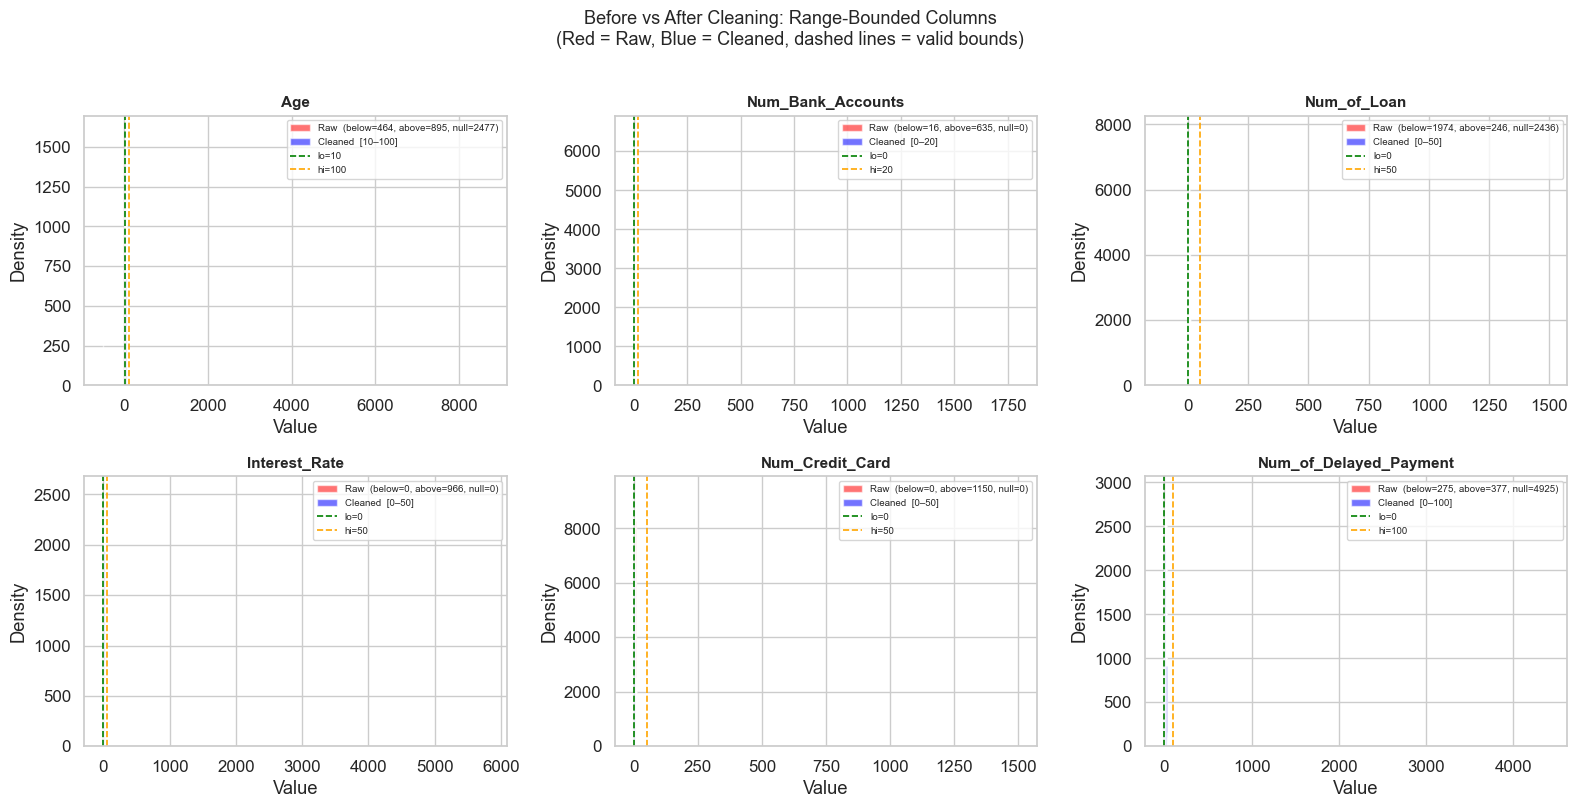

Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_cleaning_before_after.png


In [6]:

# ── 1b. Before/After Cleaning: Histogram comparison for Range-Bounded Columns ──
import matplotlib.pyplot as plt, numpy as np, os, pandas as pd
from src.preprocessing import COLUMN_BOUNDS

RAW_CSV = os.path.join(os.path.abspath('..'), 'Data', 'bank_user_dataset.csv')

_raw2 = pd.read_csv(RAW_CSV)
for c in _raw2.columns:
    _raw2[c] = pd.to_numeric(_raw2[c].astype(str).str.replace(',', ''), errors='coerce')

avail_cols = [c for c in COLUMN_BOUNDS if c in _raw2.columns and c in df_raw.columns]
ncols = 3
nrows = int(np.ceil(len(avail_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
axes = axes.flatten()

for i, col in enumerate(avail_cols):
    ax = axes[i]
    lo, hi = COLUMN_BOUNDS[col]
    raw_vals   = _raw2[col].dropna()
    clean_vals = df_raw[col].dropna()

    below = int((raw_vals < lo).sum())
    above = int((raw_vals > hi).sum())
    null  = int(_raw2[col].isna().sum())

    combined_min = min(raw_vals.min(), clean_vals.min())
    combined_max = max(raw_vals.max(), clean_vals.max())
    bins = 'auto' #np.linspace(combined_min, combined_max, 50)

    ax.hist(raw_vals,   bins=bins, alpha=0.55, color='red',  label=f'Raw  (below={below}, above={above}, null={null})', density=False)
    ax.hist(clean_vals, bins=bins, alpha=0.55, color='blue', label=f'Cleaned  [{lo}–{hi}]', density=False)
    ax.axvline(lo, color='green',  ls='--', lw=1.2, label=f'lo={lo}')
    ax.axvline(hi, color='orange', ls='--', lw=1.2, label=f'hi={hi}')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.set_xlabel('Value'); ax.set_ylabel('Density')
    ax.legend(fontsize=7)

for j in range(len(avail_cols), len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Before vs After Cleaning: Range-Bounded Columns\n(Red = Raw, Blue = Cleaned, dashed lines = valid bounds)', fontsize=13, y=1.01)
plt.tight_layout()
out_path = os.path.join(save_dir, 'plot_cleaning_before_after.png')
plt.savefig(out_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved → {out_path}")


count    12500.0
mean         4.0
std          0.0
min          4.0
25%          4.0
50%          4.0
75%          4.0
max          4.0
dtype: float64


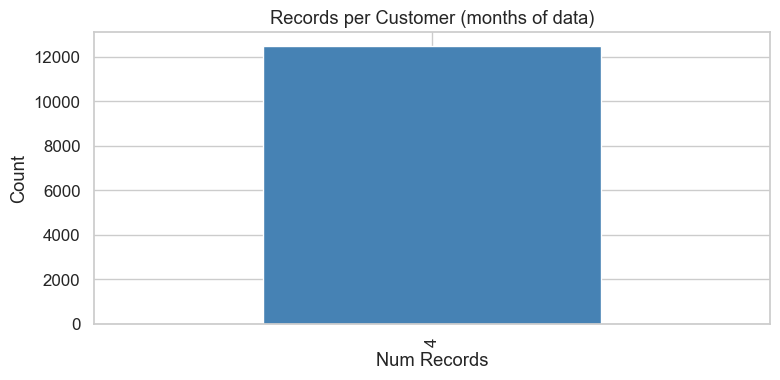

In [7]:
# ── 2. Records per customer distribution ──
rpc = df_raw.groupby('Customer_ID').size()
print(rpc.describe())

fig, ax = plt.subplots(figsize=(8, 4))
rpc.value_counts().sort_index().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Records per Customer (months of data)')
ax.set_xlabel('Num Records'); ax.set_ylabel('Count')
plt.tight_layout()
# os.makedirs('models', exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_records_per_customer.png'), dpi=150)
plt.show()

In [8]:
# ── 3. Missing value heatmap ──
missing_pct = df_raw.isnull().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
if not missing_pct.empty:
    fig, ax = plt.subplots(figsize=(10, 3))
    missing_pct.plot(kind='bar', ax=ax, color='tomato')
    ax.set_title('Missing Values (%) after cleaning')
    ax.set_ylabel('%')
    plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_missing_values.png'), dpi=150)
    plt.show()
else:
    print('No missing values after cleaning ✓')

No missing values after cleaning ✓


In [9]:
from src.utils import label_subplots
from string import ascii_uppercase
# ── 4. Key feature distributions ──
num_cols = ['Annual_Income', 'Monthly_Inhand_Salary',
            'Amount_invested_monthly', 'Outstanding_Debt',
            'Credit_Utilization_Ratio', 'Interest_Rate']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), num_cols):
    if col in df_raw.columns:
        df_raw[col].dropna().clip(
            df_raw[col].quantile(0.01), df_raw[col].quantile(0.95)
        ).hist(bins=40, ax=ax, color='steelblue', edgecolor='white')
        ax.set_title(col); ax.set_ylabel('Count')
# plt.suptitle('Feature Distributions', fontsize=13, y=1.01)
label_subplots(axes)
# # Dynamically build descriptions
# labels = [f"({ascii_uppercase[i]}) {col}" for i, col in enumerate(num_cols)]

# # Place them on the right side of the figure
# fig.text(1.02, 0.5, "\n".join(labels),
#          va='center', ha='left', fontsize=11,
#          fontweight='bold', color='black',
#          transform=fig.transFigure)

# Build dynamic description text
labels = [f"({ascii_uppercase[i]}) {str.replace(col,'_',' ')}" for i, col in enumerate(num_cols)]
line1 = " | ".join(labels[:3])   # first 3 panels
line2 = " | ".join(labels[3:])   # next 3 panels

# Add a two-line suptitle
plt.suptitle("Feature Distributions\n" + line1 + "\n" + line2,
             fontsize=13, y=1.02, fontweight='bold')

plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print(df_raw.describe())

                Age  Annual_Income  Monthly_Inhand_Salary  Num_Bank_Accounts  \
count  50000.000000   50000.000000           50000.000000       50000.000000   
mean      33.816760   52514.969419            4175.207722           5.370840   
std       10.770953   43048.787869            3152.139795           2.593355   
min       14.000000    7534.185000             530.050833           0.000000   
25%       25.000000   19453.327500            1623.593333           3.000000   
50%       33.000000   37577.820000            3081.902500           5.000000   
75%       42.000000   72817.020000            5936.446667           7.000000   
max       95.000000  251613.340000           13780.774640          11.000000   

       Num_Credit_Card  Interest_Rate   Num_of_Loan  Delay_from_due_date  \
count     50000.000000   50000.000000  50000.000000         50000.000000   
mean          5.551780      14.532080      3.535560            21.066760   
std           2.216018       8.741374      2.466904

In [10]:
# ── 5. Credit Mix distribution ──
fig, ax = plt.subplots(figsize=(6, 4))
if 'Credit_Mix' in df_raw.columns:
    df_raw['Credit_Mix'].str.strip().value_counts().plot(
        kind='bar', ax=ax, color=['#4CAF50','#FF9800','#F44336'], edgecolor='white'
    )
ax.set_title('Credit Mix Distribution')
plt.tight_layout(); plt.show()

In [11]:
# ── 6. Payment Behaviour distribution ──
fig, ax = plt.subplots(figsize=(10, 4))
if 'Payment_Behaviour' in df_raw.columns:
    df_raw['Payment_Behaviour'].str.strip().value_counts().plot(
        kind='barh', ax=ax, color='slateblue', edgecolor='white'
    )
ax.set_title('Payment Behaviour Distribution')
plt.tight_layout(); plt.show()

In [12]:
# ── 7. Per-customer feature engineering + risk labelling ──
from src.preprocessing import aggregate_per_customer, engineer_features
from src.risk_labeling  import assign_risk_label, FEATURE_WEIGHTS

df_agg  = aggregate_per_customer(df_raw)
df_feat = engineer_features(df_agg, fit_scaler=True)
df_lab  = assign_risk_label(df_feat, fit_encoder=True)

print(f'Per-customer records: {len(df_lab)}')
print(df_lab['risk_label'].value_counts())

Per-customer records: 12500
risk_label
High         3125
Low          3125
Medium       3124
Very_Low     1563
Very_High    1563
Name: count, dtype: int64


In [13]:
from src.utils import label_subplots
# ── 7a. Inspect the 3 new features (v2) ──
new_feats = ['EMI_Income_Ratio', 'Savings_Rate', 'Credit_History_Score']
print("=== New Derived Features (v2) ===")
for feat in new_feats:
    if feat in df_lab.columns:
        vals = df_lab[feat]
        print(f"  {feat:25s}  min={vals.min():.4f}  mean={vals.mean():.4f}  max={vals.max():.4f}")
    else:
        print(f"  {feat:25s}  NOT FOUND in df_lab")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, feat in zip(axes, new_feats):
    if feat in df_lab.columns:
        df_lab[feat].hist(bins=50, ax=ax, color='teal', edgecolor='white', alpha=0.8)
        ax.set_title(feat)
        ax.set_ylabel('Count')
plt.suptitle('New Derived Features (v2)', fontsize=13, y=1.02)
label_subplots(axes)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_new_features_v2.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f"\nAll {len(new_feats)} new features present and non-null")

=== New Derived Features (v2) ===
  EMI_Income_Ratio           min=0.0000  mean=0.1000  max=1.0000
  Savings_Rate               min=0.0000  mean=0.8839  max=1.0000
  Credit_History_Score       min=0.0000  mean=0.5471  max=1.0000



All 3 new features present and non-null


---
## Raw Risk Score Distribution — Before Bell-Curve Binning

The composite score `Σ(weight × feature)` is a continuous number.  
**Bell-curve `pd.qcut` bins** are applied using `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`, giving:

| Class | Quantile Range | Target % |
|-------|---------------|----------|
| Very_Low | 0% – 12.5% | **12.5%** |
| Low | 12.5% – 37.5% | **25.0%** |
| Medium | 37.5% – 62.5% | **25.0%** |
| High | 62.5% – 87.5% | **25.0%** |
| Very_High | 87.5% – 100% | **12.5%** |

The plots below show the raw score shape and the final label distribution after binning.


In [14]:
from src.utils import label_subplots
# ── 7b. Raw risk score distribution — before bell-curve qcut ──────────────────
from src.risk_labeling import compute_risk_score, FEATURE_WEIGHTS, RISK_QUANTILES
from config import RISK_CLASSES

# Compute raw scores on the per-customer feature-engineered data
raw_scores = compute_risk_score(df_feat)

print(f"Raw risk score range: {raw_scores.min():.4f} to {raw_scores.max():.4f}")

# Compute the BELL-CURVE boundaries (RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0])
quintile_edges = pd.qcut(raw_scores, q=RISK_QUANTILES, retbins=True)[1]

print("=== Raw Risk Score Statistics (before bell-curve qcut) ===")
print(raw_scores.describe().round(4).to_string())
print(f"\nBell-curve qcut boundaries (RISK_QUANTILES={RISK_QUANTILES}): {[round(b, 3) for b in quintile_edges]}")
print(f"\nCustomers per bin after bell-curve qcut:")
binned = pd.qcut(raw_scores, q=RISK_QUANTILES, labels=RISK_CLASSES)
counts_binned = binned.value_counts().reindex(RISK_CLASSES)
total = len(raw_scores)
for cls, cnt in counts_binned.items():
    pct = 100 * cnt / total
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%)")

# Also check df_lab (actual labels from assign_risk_label)
print(f"\nActual label counts in df_lab (from assign_risk_label, should match above):")
actual_counts = df_lab['risk_label'].value_counts().reindex(RISK_CLASSES)
for cls, cnt in actual_counts.items():
    pct = 100 * cnt / len(df_lab)
    print(f"  {cls:<12}: {cnt:5d}  ({pct:.1f}%) {'✓' if abs(pct - ([12.5,25,25,25,12.5][RISK_CLASSES.index(cls)])) < 1 else '✗'}")

PALETTE = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
           'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))


# ── Plot 1: Raw histogram + KDE with bell-curve boundaries ────────────────────
ax = axes[0]
ax.hist(raw_scores, bins=60, color='steelblue', alpha=0.7, edgecolor='white',
        density=True, label='Histogram (density)')
raw_scores.plot(kind='kde', ax=ax, color='navy', linewidth=2, label='KDE')
for edge in quintile_edges[1:-1]:
    ax.axvline(edge, color='crimson', linestyle='--', linewidth=1.2)
ax.axvline(quintile_edges[1], color='crimson', linestyle='--', linewidth=1.2,
           label='Bell-curve bin boundaries')
ax.set_title("Raw Risk Score — Histogram + KDE\n(dashed lines = bell-curve bin edges)")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=8)

# ── Plot 2: Boxplot of per-class score ranges ─────────────────────────────────
ax = axes[1]
score_df = pd.DataFrame({'risk_score': raw_scores.values,
                          'risk_label': df_lab['risk_label'].values})
for i, label in enumerate(RISK_CLASSES):
    subset = score_df[score_df['risk_label'] == label]['risk_score']
    ax.boxplot(subset, positions=[i], widths=0.5,
               patch_artist=True,
               boxprops=dict(facecolor=PALETTE[label], alpha=0.6),
               medianprops=dict(color='black', linewidth=2),
               whiskerprops=dict(linewidth=1.2),
               capprops=dict(linewidth=1.2),
               flierprops=dict(marker='.', alpha=0.3, markersize=3))
ax.set_xticks(range(len(RISK_CLASSES)))
ax.set_xticklabels(RISK_CLASSES, rotation=20, ha='right')
ax.set_title("Score Range per Risk Class (after bell-curve qcut)")
ax.set_xlabel("Risk Label")
ax.set_ylabel("Raw Risk Score")

# ── Plot 3: Actual label distribution bar chart (bell-curve result) ───────────
ax = axes[2]
TARGET_PCT = {'Very_Low': 12.5, 'Low': 25.0, 'Medium': 25.0, 'High': 25.0, 'Very_High': 12.5}
bars = ax.bar(RISK_CLASSES,
              [100 * actual_counts[c] / len(df_lab) for c in RISK_CLASSES],
              color=[PALETTE[c] for c in RISK_CLASSES],
              edgecolor='white', alpha=0.85)
# Target line overlay
for i, cls in enumerate(RISK_CLASSES):
    ax.axhline(TARGET_PCT[cls], xmin=(i + 0.1) / len(RISK_CLASSES),
               xmax=(i + 0.9) / len(RISK_CLASSES),
               color='black', linestyle='--', linewidth=1.5)
# Value labels on bars
for bar, cls in zip(bars, RISK_CLASSES):
    pct = 100 * actual_counts[cls] / len(df_lab)
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{pct:.1f}%\n(n={actual_counts[cls]:,})',
            ha='center', va='bottom', fontsize=8.5, fontweight='bold')
ax.set_title("Actual Label Distribution After Bell-Curve Binning\n(─ ─  = target %)")
ax.set_xlabel("Risk Class")
ax.set_ylabel("Customers (%)")
ax.set_ylim(0, 35)
ax.tick_params(axis='x', rotation=15)

labels = ['(A) Scree Plot','(B) PC1 Loading','(C) PCA Risk Score Distribution']
line1 = " | ".join(labels[:3])   # first 3 panels

fig.suptitle("Risk Score Distribution — Bell-Curve Binning (12.5 / 25 / 25 / 25 / 12.5%)\n" + line1,
             fontsize=14, fontweight='bold')

label_subplots(axes, y =-0.25)
plt.tight_layout()

# Save
import os
save_dir = os.path.join(os.path.abspath('..'), 'models')
os.makedirs(save_dir, exist_ok=True)
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%")
print(f"  RISK_QUANTILES used: {RISK_QUANTILES}")


Raw risk score range: -5.3008 to 6.2947
=== Raw Risk Score Statistics (before bell-curve qcut) ===
count    12500.0000
mean         0.6578
std          2.4917
min         -5.3008
25%         -1.4512
50%          0.8160
75%          2.7035
max          6.2947

Bell-curve qcut boundaries (RISK_QUANTILES=[0.0, 0.125, 0.375, 0.625, 0.875, 1.0]): [-5.301, -2.697, -0.001, 1.639, 3.665, 6.295]

Customers per bin after bell-curve qcut:
  Very_Low    :  1563  (12.5%)
  Low         :  3125  (25.0%)
  Medium      :  3124  (25.0%)
  High        :  3125  (25.0%)
  Very_High   :  1563  (12.5%)

Actual label counts in df_lab (from assign_risk_label, should match above):
  Very_Low    :  1563  (12.5%) ✓
  Low         :  3125  (25.0%) ✓
  Medium      :  3124  (25.0%) ✓
  High        :  3125  (25.0%) ✓
  Very_High   :  1563  (12.5%) ✓



✓ Bell-curve binning confirmed: Very_Low≈12.5%, Low≈25%, Medium≈25%, High≈25%, Very_High≈12.5%
  RISK_QUANTILES used: [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]


In [15]:
# ── KDE overlay: raw score for each risk class (bell-curve shape confirmed) ───
fig, ax = plt.subplots(figsize=(9, 4))
for cls in RISK_CLASSES:
    subset_scores = score_df[score_df['risk_label'] == cls]['risk_score']
    sns.kdeplot(subset_scores, fill=True, alpha=0.35, color=PALETTE[cls],
                label=f"{cls} (n={len(subset_scores):,})", ax=ax)
ax.set_title("Risk Score KDE per Class — Bell-Curve Binning")
ax.set_xlabel("Composite Risk Score")
ax.set_ylabel("Density")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'plot_raw_risk_score_distribution1.png'), dpi=150, bbox_inches='tight')
plt.show()


In [16]:
# ── 8. Risk label distribution ──
from src.utils import plot_risk_distribution

plot_risk_distribution(
    df_lab['risk_label'].values,
    title='Risk Appetite Distribution — All Customers (5 Classes)',
    save_path=os.path.join(save_dir, 'plot_risk_distribution.png')
)

Saved distribution plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_risk_distribution.png


In [17]:
# ── 9. Feature importance (domain weights) ──
from src.utils import plot_feature_importance

plot_feature_importance(
    FEATURE_WEIGHTS,
    save_path=os.path.join(save_dir, 'plot_feature_importance.png')
)

Saved feature importance plot → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_feature_importance.png


In [18]:
# ── 10. Correlation heatmap of engineered features ──
from config import RISK_FEATURES

feat_available = [f for f in RISK_FEATURES if f in df_lab.columns]
corr = df_lab[feat_available].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, linewidths=0.5)
ax.set_title('Feature Correlation Matrix')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_feature_correlation.png'), dpi=150)
plt.show()

In [19]:
# ── 11. Mutual Fund EDA ──
from src.recommender import load_mutual_funds

mf_df = load_mutual_funds()
print(f'Mutual Fund catalogue: {len(mf_df)} funds, {mf_df["AMC"].nunique()} AMCs')

print('\nRisk Tier Assignment:')
print(mf_df['risk_tier'].value_counts(dropna=False))

Mutual Fund catalogue: 14330 funds, 51 AMCs

Risk Tier Assignment:
risk_tier
Low          6054
Very_High    4294
Medium       2264
High         1033
Very_Low      685
Name: count, dtype: int64


In [20]:
# ── 12. Mutual fund risk tier distribution (ordered Very_Low → Very_High) ──
from config import RISK_CLASSES as RC_MF
PALETTE_TIER = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
                'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}
mf_tier = mf_df['risk_tier'].dropna().value_counts().reindex(RC_MF, fill_value=0)
fig, ax = plt.subplots(figsize=(9, 4))
mf_tier.plot(kind='bar', ax=ax,
             color=[PALETTE_TIER[t] for t in RC_MF],
             edgecolor='white')
ax.set_title('Mutual Fund Count by Risk Tier')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('Number of Funds')
for bar, cnt_val in zip(ax.patches, mf_tier.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{cnt_val:,}', ha='center', va='bottom', fontsize=8.5, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_mf_risk_tiers.png'), dpi=150)
plt.show()


In [21]:
# ── 13. AUM distribution by risk tier (ordered Very_Low → Very_High) ──
fig, ax = plt.subplots(figsize=(10, 5))
mf_df_plot = mf_df.dropna(subset=['risk_tier', 'Average_AUM_Cr']).copy()
mf_df_plot['Average_AUM_Cr_log'] = np.log1p(
    pd.to_numeric(mf_df_plot['Average_AUM_Cr'], errors='coerce').fillna(0))
RC_ordered = [r for r in RC_MF if r in mf_df_plot['risk_tier'].unique()]
sns.boxplot(data=mf_df_plot, x='risk_tier', y='Average_AUM_Cr_log',
            order=RC_ordered, ax=ax,
            palette={r: PALETTE_TIER[r] for r in RC_ordered},
            linewidth=0.8, fliersize=2)
ax.set_title('log(1+AUM) by Risk Tier — ordered Very_Low → Very_High\n'
             '(Liquid/overnight funds attract highest institutional AUM)')
ax.set_xlabel('Risk Tier'); ax.set_ylabel('log1p(AUM in Cr)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_aum_by_tier.png'), dpi=150)
plt.show()


In [22]:
# ── 14. Investment ratio vs risk label ──
fig, ax = plt.subplots(figsize=(9, 4))
for label in df_lab['risk_label'].unique():
    ax.hist(
        df_lab[df_lab['risk_label'] == label]['Investment_Ratio'].clip(0, 2),
        bins=30, alpha=0.5, label=label, density=True
    )
ax.set_title('Investment Ratio Distribution by Risk Label')
ax.set_xlabel('Investment Ratio (capped at 2)')
ax.legend()
plt.tight_layout(); plt.savefig(os.path.join(save_dir, 'plot_inv_ratio_by_risk.png'), dpi=150)
plt.show()

In [23]:
# ── 15. NAV History — quick stats and reference date ──
from src.nav_history import nav_history_quick_stats, load_nav_metrics, _ref_date
from config import NAV_HISTORY_PARQUET

import os
if not NAV_HISTORY_PARQUET.exists():
    print(f"Parquet not found at: {NAV_HISTORY_PARQUET}")
else:
    stats = nav_history_quick_stats()
    ref   = _ref_date()

    print("─── NAV History Parquet — Quick Stats ───")
    print(f"  File            : {NAV_HISTORY_PARQUET.name}")
    print(f"  Total rows      : {stats['total_rows']:>12,}")
    print(f"  Schemes (sample): {stats['sample_schemes']:>12,}")
    print(f"  Date range      : {stats['sample_date_min'].date()} → {stats['sample_date_max'].date()}")
    print(f"  Reference date  : {ref.date()}  ← latest NAV date in parquet")
    print(f"  Row groups      : {stats['num_row_groups']}")
    print()

    nav_metrics = load_nav_metrics(verbose=True)
    print()
    print("─── NAV Metrics Cache — Summary ─────────")
    print(nav_metrics[['cagr_1yr','cagr_3yr','cagr_5yr',
                        'sharpe_1yr','max_drawdown','record_count']].describe().round(4))


─── NAV History Parquet — Quick Stats ───
  File            : mutual_fund_nav_history.parquet
  Total rows      :   21,456,636
  Schemes (sample):          222
  Date range      : 2006-04-01 → 2026-03-12
  Reference date  : 2026-03-12  ← latest NAV date in parquet
  Row groups      : 21

[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,501 scheme metrics from cache.

─── NAV Metrics Cache — Summary ─────────
         cagr_1yr    cagr_3yr    cagr_5yr  sharpe_1yr  max_drawdown  \
count  13714.0000  12159.0000  10315.0000   7988.0000     9154.0000   
mean       0.0533      0.0523      0.0370     -0.7646       -0.1017   
std        0.1503      0.0826      0.0715      2.6766        0.1087   
min       -0.9813     -0.5263     -0.6019    -10.0000       -0.9905   
25%        0.0000      0.0000      0.0000     -0.8443       -0.1845   
50%        0.0000      0.0001      0.0025      0.0621       -0.0687   


---
## Mutual Fund Dataset — Data Preparation & EDA

The sections below document preparation steps applied to the **mutual fund catalogue**.

### Columns Removed (EDA Decision)

| Column | Null % | Reason Dropped |
|---|---|---|
| `ISIN_Div_Payout/Growth` | 12.5 % | Identifier code — not a model feature |
| `ISIN_Div_Reinvestment` | 12.5 % | Identifier code — not a model feature |
| `ISIN_Div_Payout/Growth/Div_Reinvestment` | 8.6 % | Identifier code — not a model feature |
| `AAUM_Quarter` | 51.0 % | Quarter string label — entirely redundant with `Average_AUM_Cr` |

### Columns Retained
`Scheme_Code`, `Scheme_Name`, `AMC`, `Scheme_Type`, `Scheme_Category`,
`Scheme_NAV_Name`, `Scheme_Min_Amt`, `NAV`, `Latest_NAV_Date`,
`Average_AUM_Cr`, `Launch_Date`, `Closure_Date`

→ **12 columns** (down from 16).  All columns kept are used in the downstream modelling pipeline.

In [24]:

# ── MF-1. Load fund catalogue — raw vs clean comparison ───────────────────────
import pandas as pd
import numpy as np
import sys, os
sys.path.insert(0, os.path.abspath('..'))
from src.recommender import load_mutual_funds
from config import RISK_CLASSES

raw_mf   = pd.read_csv('../Data/mutual_fund_data.csv',       low_memory=False)
clean_mf = pd.read_csv('../Data/mutual_fund_data_clean.csv', low_memory=False)
raw_mf.columns   = [c.strip() for c in raw_mf.columns]
clean_mf.columns = [c.strip() for c in clean_mf.columns]

print(f"Raw   mutual fund catalogue : {len(raw_mf):,} rows × {raw_mf.shape[1]} columns")
print(f"Clean mutual fund catalogue : {len(clean_mf):,} rows × {clean_mf.shape[1]} columns")
print(f"  Columns removed by EDA    : {raw_mf.shape[1] - clean_mf.shape[1]}")
dropped_cols = [c for c in raw_mf.columns if c not in clean_mf.columns]
print(f"  Dropped                   : {dropped_cols}")
print(f"\nClean columns ({len(clean_mf.columns)}): {list(clean_mf.columns)}")
print(f"\nUnique AMCs       : {clean_mf['AMC'].nunique()}")
print(f"Unique categories : {clean_mf['Scheme_Category'].nunique()}")

# Missing value comparison
print("\n=== Missing Value Summary — BEFORE vs AFTER EDA Cleaning ===")
raw_miss  = (raw_mf.isnull().sum() / len(raw_mf) * 100).round(2)
clean_miss = (clean_mf.isnull().sum() / len(clean_mf) * 100).round(2)
miss_df = pd.DataFrame({'Raw %': raw_miss, 'Clean %': clean_miss}).query('`Raw %` > 0 or `Clean %` > 0')
print(miss_df.to_string())

# NAV filter
nav_numeric   = pd.to_numeric(raw_mf['NAV'], errors='coerce')
actually_null = nav_numeric.isna().sum()
print(f"\n  Rows dropped at load for null NAV: {actually_null:,} ({100*actually_null/len(raw_mf):.2f}%)")
print(f"  Rows retained after NAV filter   : {len(raw_mf) - actually_null:,}")
print()
print("Treatment for remaining nulls:")
print("  Average_AUM_Cr  → filled with 0 before log1p transform")
print("  Scheme_Min_Amt  → filled with 500 (SEBI default) before log1p")
print("  Launch_Date     → NaT → fund_age_years = 0")
print("  Closure_Date    → NaT → is_active = 1 (open-ended fund)")
print("  Latest_NAV_Date → NaT → nav_recency_days = 365 (dormant proxy)")

Raw   mutual fund catalogue : 16,376 rows × 16 columns
Clean mutual fund catalogue : 16,376 rows × 12 columns
  Columns removed by EDA    : 4
  Dropped                   : ['AAUM_Quarter', 'ISIN_Div_Payout/Growth', 'ISIN_Div_Reinvestment', 'ISIN_Div_Payout/Growth/Div_Reinvestment']

Clean columns (12): ['Scheme_Code', 'Scheme_Name', 'AMC', 'Scheme_Type', 'Scheme_Category', 'Scheme_NAV_Name', 'Scheme_Min_Amt', 'NAV', 'Latest_NAV_Date', 'Average_AUM_Cr', 'Launch_Date', 'Closure_Date']

Unique AMCs       : 53
Unique categories : 50

=== Missing Value Summary — BEFORE vs AFTER EDA Cleaning ===
                                         Raw %  Clean %
AAUM_Quarter                             50.93      NaN
Average_AUM_Cr                           50.93    50.93
Closure_Date                             76.40    76.40
ISIN_Div_Payout/Growth                   12.49      NaN
ISIN_Div_Payout/Growth/Div_Reinvestment   8.56      NaN
ISIN_Div_Reinvestment                    12.49      NaN
Latest_NAV_

In [25]:
import matplotlib.pyplot as plt, seaborn as sns, warnings
warnings.filterwarnings('ignore')

# ── MF-1b. Mutual Fund Dataset — Raw Column Correlation Matrix ────────────────
from sklearn.preprocessing import LabelEncoder
le2 = LabelEncoder()

df_fc = clean_mf.copy()
df_fc['NAV_clean']  = pd.to_numeric(df_fc['NAV'],  errors='coerce')
df_fc['AUM_clean']  = pd.to_numeric(df_fc['Average_AUM_Cr'], errors='coerce')
df_fc['MinAmt']     = pd.to_numeric(df_fc['Scheme_Min_Amt'].astype(str)
                        .str.replace(',','').str.extract(r'([\d.]+)')[0], errors='coerce')
df_fc['Launch_Year'] = pd.to_datetime(df_fc['Launch_Date'], errors='coerce').dt.year
df_fc['Is_Active']   = df_fc['Closure_Date'].isna().astype(int)
df_fc['Type_enc']    = le2.fit_transform(df_fc['Scheme_Type'].fillna('Unknown'))
df_fc['Cat_enc']     = le2.fit_transform(df_fc['Scheme_Category'].fillna('Unknown'))
df_fc['AMC_enc']     = le2.fit_transform(df_fc['AMC'].fillna('Unknown'))

fc_cols = ['NAV_clean','AUM_clean','MinAmt','Launch_Year','Is_Active',
           'Type_enc','Cat_enc','AMC_enc']
fc_cols = [c for c in fc_cols if c in df_fc.columns]
corr_fund = df_fc[fc_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(10, 8))
mask_f = np.triu(np.ones_like(corr_fund, dtype=bool))
sns.heatmap(corr_fund, ax=ax, mask=mask_f, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f', annot_kws={'size':9},
            linewidths=0.5, square=True)
ax.set_title('Mutual Fund Dataset — Feature Correlation Matrix\n(clean dataset, 12 columns)', fontsize=12)
plt.tight_layout()
plt.savefig('../eda_outputs/fund_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nHighly correlated pairs (|r| > 0.70):")
found_f = False
for i in range(len(corr_fund.columns)):
    for j in range(i+1, len(corr_fund.columns)):
        v = corr_fund.iloc[i,j]
        if abs(v) > 0.70:
            print(f"  {corr_fund.columns[i]} ↔ {corr_fund.columns[j]}  r={v:.3f}")
            found_f = True
if not found_f:
    print("  → None found above 0.70 threshold.")


Highly correlated pairs (|r| > 0.70):
  → None found above 0.70 threshold.


In [26]:
from src.utils import label_subplots

# ── MF-2. Univariate analysis: NAV, AUM, Scheme_Type, active/inactive ─────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

mf_clean = raw_mf.copy()
mf_clean['NAV']             = pd.to_numeric(mf_clean['NAV'], errors='coerce')
mf_clean['Average_AUM_Cr']  = pd.to_numeric(mf_clean['Average_AUM_Cr'], errors='coerce')
mf_clean['Scheme_Min_Amt']  = pd.to_numeric(mf_clean['Scheme_Min_Amt'], errors='coerce')
mf_clean['Closure_Date']    = pd.to_datetime(mf_clean['Closure_Date'], errors='coerce')
mf_clean = mf_clean[mf_clean['NAV'].notna()].copy()

print(f"Funds retained after NAV filter: {len(mf_clean):,}")
print()

# ── Scheme_Type breakdown
stype = mf_clean['Scheme_Type'].value_counts()
print("Scheme_Type breakdown:")
for t, c in stype.items():
    print(f"  {t:<30}: {c:5,}  ({100*c/len(mf_clean):.1f}%)")

# ── Active vs Inactive
n_active   = mf_clean['Closure_Date'].isna().sum()
n_inactive = mf_clean['Closure_Date'].notna().sum()
print(f"\nActive funds  (no Closure_Date) : {n_active:,}  ({100*n_active/len(mf_clean):.1f}%)")
print(f"Inactive funds (has Closure_Date): {n_inactive:,}  ({100*n_inactive/len(mf_clean):.1f}%)")

print(f"\nNAV stats (raw):")
print(mf_clean['NAV'].describe().round(2).to_string())
print(f"\nAverage_AUM_Cr stats (raw):")
print(mf_clean['Average_AUM_Cr'].describe().round(2).to_string())

# ── Visualisation
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#fig.suptitle("Mutual Fund Catalogue — Univariate Analysis", fontsize=14, fontweight='bold')

# (1) NAV raw — right skew
ax = axes[0, 0]
nav_clip = mf_clean['NAV'].clip(upper=mf_clean['NAV'].quantile(1.0))
ax.hist(nav_clip, bins=80, color='steelblue', edgecolor='white', alpha=0.8)
ax.set_title("NAV Distribution \nMotivates log-transform")
ax.set_xlabel("NAV (₹)"); ax.set_ylabel("Fund Count")
ax.axvline(mf_clean['NAV'].median(), color='crimson', ls='--', label=f'Median={mf_clean["NAV"].median():.1f}')
ax.legend(fontsize=8)

# (2) NAV log-transformed
ax = axes[0, 1]
ax.hist(np.log1p(mf_clean['NAV'].dropna()), bins=80, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("log(1+NAV) Distribution\n(nav_log feature in ensemble)")
ax.set_xlabel("log(1 + NAV)"); ax.set_ylabel("Fund Count")

# (3) AUM log-transformed
ax = axes[0, 2]
ax.hist(np.log1p(mf_clean['Average_AUM_Cr'].fillna(0)), bins=80, color='seagreen', edgecolor='white', alpha=0.8)
ax.set_title("log(1+AUM) Distribution\n(log_aum feature in ensemble)")
ax.set_xlabel("log(1 + AUM in Cr)"); ax.set_ylabel("Fund Count")

# (4) Scheme_Type pie
ax = axes[1, 0]
stype_top = stype.head(4)
ax.pie(stype_top.values, labels=stype_top.index, autopct='%1.1f%%',
       colors=['#2196F3','#4CAF50','#FF9800','#9C27B0'], startangle=90)
ax.set_title("Scheme_Type Breakdown\n(is_open_ended flag)")

# (5) Active vs Inactive  
ax = axes[1, 1]
ax.bar(['Active\n(no Closure_Date)', 'Inactive\n(has Closure_Date)'],
       [n_active, n_inactive],
       color=['#4CAF50', '#F44336'], edgecolor='white', alpha=0.85)
ax.set_title("Active vs Inactive Funds\n(is_active flag)")
ax.set_ylabel("Fund Count")
for bar, val in zip(ax.patches, [n_active, n_inactive]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
            f'{val:,}\n({100*val/len(mf_clean):.1f}%)', ha='center', fontsize=9, fontweight='bold')

# (6) Scheme_Min_Amt distribution
ax = axes[1, 2]
min_amt = mf_clean['Scheme_Min_Amt'].dropna()
ax.hist(np.log1p(min_amt.clip(upper=min_amt.quantile(0.99))), bins=60,
        color='#9C27B0', edgecolor='white', alpha=0.8)
ax.set_title("log(1+Min Investment) Distribution\n(min_inv_log feature in ensemble)")
ax.set_xlabel("log(1 + Scheme_Min_Amt)"); ax.set_ylabel("Fund Count")

label_subplots(axes)
labels = ['(A) NAV Distribution' ,'(B) log(1+NAV) Distribution', '(C) log(1+AUM) Distribution', '(D) Scheme Type Breakdown', '(E) Active/InActive Funds', '(F) log (1+Min Investment) Distribution' ]
line1 = " | ".join(labels[:3])   # first 3 panels
line2 = " | ".join(labels[3:])   # next 3 panels

# Add a two-line suptitle
fig.suptitle("Mutual Fund Catalogue — Univariate Analysis\n" + line1 + "\n" + line2,
             fontsize=13, y=1.02, fontweight='bold')

plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_univariate.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


Funds retained after NAV filter: 14,330

Scheme_Type breakdown:
  Open Ended                    : 9,333  (65.1%)
  Close Ended                   : 4,935  (34.4%)
  Interval Fund                 :    62  (0.4%)

Active funds  (no Closure_Date) : 10,713  (74.8%)
Inactive funds (has Closure_Date): 3,617  (25.2%)

NAV stats (raw):
count      14330.00
mean        1626.28
std        52056.37
min            0.00
25%           10.86
50%           13.05
75%           28.89
max      2413698.27

Average_AUM_Cr stats (raw):
count      8031.00
mean       1020.62
std        4918.52
min           0.00
25%           0.59
50%          12.35
75%         231.48
max      213610.11


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_univariate.png


In [27]:
from src.utils import label_subplots

# ── MF-3. Synthetic Expense Ratio + AMC Frequency Encoding ───────────────────
# The raw CSV has NO Total Expense Ratio column.
# Source: src/ensemble_recommender.build_fund_features() and src/recommender.load_mutual_funds()
#
# Formula (from code):
#   base_er = 1.50 - 1.20 × is_index - 0.70 × is_debt
#   synth_expense_ratio = (base_er - 0.30 × amc_size_norm).clip(0.05, 2.50)
#   expense_ratio_norm  = synth_expense_ratio / 2.50   → [0, 1] for model input
#
# Rationale:
#   - Index/ETF funds: historically low TER (~0.10–0.30%)
#   - Active debt funds: medium TER (~0.30–0.80%)
#   - Active equity funds: higher TER (~1.0–1.75%)
#   - Larger AMCs (by fund count) receive a discount (economies of scale)
#
# This feature ranks 3rd in the ensemble by feature importance.

from config import RISK_CLASSES, MODELS_DIR

# Reconstruct the synthetic columns step by step on the cleaned catalogue
mf = mf_clean.copy()

# Step 1: tier ordinal (needed for is_debt flag)
from config import RISK_CLASSES as RC
tier_map = {r: i for i, r in enumerate(RC)}
from src.recommender import load_mutual_funds
mf_loaded = load_mutual_funds()           # fully cleaned, with risk_tier assigned
mf_loaded['tier_ord'] = mf_loaded['risk_tier'].map(tier_map)

nav_name_s  = mf_loaded.get('Scheme_NAV_Name', '').fillna('').str.lower()
is_index    = nav_name_s.str.contains('index|etf|nifty|sensex', regex=True).astype(float)
is_debt     = (mf_loaded['tier_ord'] <= 1.0).astype(float)
amc_s       = mf_loaded['AMC'].fillna('Other')
amc_cnt     = amc_s.map(amc_s.value_counts()).fillna(1)
amc_norm    = amc_cnt / amc_cnt.max()

base_er = 1.50 - 1.20 * is_index - 0.70 * is_debt
mf_loaded['synth_expense_ratio'] = (base_er - 0.30 * amc_norm).clip(0.05, 2.50).round(3)

print("=== Expense Ratio — Construction Summary ===")
print(f"No raw TER column in CSV → derived from fund traits")
print(f"Formula: (1.50 - 1.20×is_index - 0.70×is_debt) - 0.30×amc_size_norm,  clipped [0.05, 2.50]")
print()
print(mf_loaded['synth_expense_ratio'].describe().round(3).to_string())
print()

# Per-type breakdown
mf_loaded['is_index'] = is_index.values
mf_loaded['is_debt']  = is_debt.values
print("Mean synth_expense_ratio by fund type:")
for label, mask in [('Index / ETF', mf_loaded['is_index'] == 1),
                    ('Debt (tier ≤ Low)', mf_loaded['is_debt'] == 1),
                    ('Active Equity', (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 0))]:
    sub = mf_loaded.loc[mask, 'synth_expense_ratio']
    print(f"  {label:<25}: mean={sub.mean():.3f}  median={sub.median():.3f}  n={len(sub):,}")

# AMC frequency encoding
print("\n=== AMC Frequency Encoding (amc_size_norm) ===")
print("Top 10 AMCs by fund count (amc_size_norm = count / max_count):")
top10 = amc_s.value_counts().head(10)
max_c = top10.iloc[0]
for amc, cnt in top10.items():
    print(f"  {amc:<45}: {cnt:4d} funds  amc_size_norm={cnt/amc_cnt.max():.3f}")

# Visualisation
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Mutual Fund Feature Engineering — Expense Ratio & AMC Encoding",
             fontsize=13, fontweight='bold')

# (1) synth_expense_ratio distribution
ax = axes[0]
for label, mask, color in [
    ('Index/ETF',         mf_loaded['is_index'] == 1, '#2196F3'),
    ('Debt',              (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 1), '#4CAF50'),
    ('Active Equity',     (mf_loaded['is_index'] == 0) & (mf_loaded['is_debt'] == 0), '#F44336'),
]:
    ax.hist(mf_loaded.loc[mask, 'synth_expense_ratio'], bins=40, alpha=0.65, label=label, color=color)
ax.set_title("Expense Ratio Distribution\n(no raw TER in CSV — constructed from traits)")
ax.set_xlabel("Synth TER (%)"); ax.set_ylabel("Fund Count")
ax.legend(fontsize=8)
ax.axvline(2.5, color='grey', ls=':', lw=1.2, label='clip ceiling')

# (2) synth_expense_ratio by risk tier
ax = axes[1]
tier_er = mf_loaded.groupby('risk_tier')['synth_expense_ratio'].median().reindex(RC)
colors_t = ['#2196F3','#4CAF50','#FF9800','#F44336','#9C27B0']
bars = ax.bar(tier_er.index, tier_er.values, color=colors_t, edgecolor='white', alpha=0.85)
ax.set_title("Median Synth Expense Ratio by Risk Tier\n(lower tier → lower cost)")
ax.set_xlabel("Risk Tier"); ax.set_ylabel("Median TER (%)")
plt.setp(ax.get_xticklabels(), rotation=25, ha='right')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.3f}%', ha='center', fontsize=8, fontweight='bold')

# (3) AMC size norm distribution
ax = axes[2]
ax.hist(amc_norm, bins=40, color='darkorange', edgecolor='white', alpha=0.8)
ax.set_title("AMC Size Norm Distribution\n(amc_size_norm = fund_count_for_AMC / max)")
ax.set_xlabel("amc_size_norm"); ax.set_ylabel("Fund Count")
ax.axvline(amc_norm.median(), color='crimson', ls='--',
           label=f'Median={amc_norm.median():.3f}')
ax.legend(fontsize=8)

label_subplots(axes)
plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_feature_engineering.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")
print(f"\nNote: expense_ratio_norm = synth_expense_ratio / 2.50 → normalised to [0,1] as model input")
print(f"      This feature ranks 3rd in ensemble importance (Table 4.8.3 in thesis).")


=== Expense Ratio — Construction Summary ===
No raw TER column in CSV → derived from fund traits
Formula: (1.50 - 1.20×is_index - 0.70×is_debt) - 0.30×amc_size_norm,  clipped [0.05, 2.50]

count    14330.000
mean         0.899
std          0.462
min          0.050
25%          0.570
50%          0.752
75%          1.442
max          1.500

Mean synth_expense_ratio by fund type:
  Index / ETF              : mean=0.202  median=0.248  n=1,817
  Debt (tier ≤ Low)        : mean=0.618  median=0.636  n=6,739
  Active Equity            : mean=1.412  median=1.450  n=5,922

=== AMC Frequency Encoding (amc_size_norm) ===
Top 10 AMCs by fund count (amc_size_norm = count / max_count):
  ICICI Prudential Asset Management Company Limited: 2488 funds  amc_size_norm=1.000
  Nippon Life India Asset Management Limited   : 1908 funds  amc_size_norm=0.767
  UTI Asset Mgmt. Co. Ltd.                     : 1362 funds  amc_size_norm=0.547
  Kotak Mahindra Asset Management Company Limited.:  891 funds  amc_size

✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_feature_engineering.png

Note: expense_ratio_norm = synth_expense_ratio / 2.50 → normalised to [0,1] as model input
      This feature ranks 3rd in ensemble importance (Table 4.8.3 in thesis).


In [28]:

# ── MF-4. CATEGORY_RISK_BOUNDS: SEBI Floor/Ceiling Clamp Analysis ─────────────
# After data-driven tier assignment from NAV volatility/drawdown percentile bands,
# config.CATEGORY_RISK_BOUNDS enforces SEBI-aligned min/max tier constraints.
# E.g. overnight funds are always Very_Low (0,0); small-cap min=High (floor=3).
#
# Reference: SEBI Circular SEBI/HO/IMD/DF2/CIR/P/2019/17 — product risk-o-meter.
# Source:    config.py → CATEGORY_RISK_BOUNDS dict; src/nav_history.py → compute_fund_risk_bands()

from config import CATEGORY_RISK_BOUNDS, RISK_CLASSES as RC

# Show the full bounds table
print("=== CATEGORY_RISK_BOUNDS — SEBI Floor/Ceiling Clamp Table ===")
print(f"{'Category Keyword':<30}  {'Floor':<12}  {'Ceiling':<12}  {'Allowed Range'}")
print("─" * 78)
for cat, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    floor_label   = RC[fl]
    ceiling_label = RC[ce]
    allowed = " → ".join(RC[fl:ce+1]) if fl != ce else RC[fl]
    print(f"  {cat:<28}  {floor_label:<12}  {ceiling_label:<12}  {allowed}")

# Count how many funds from the loaded catalogue have a tier that hits a boundary
mf_loaded_check = mf_loaded.copy()
mf_loaded_check['tier_ord_check'] = mf_loaded_check['risk_tier'].map({r: i for i, r in enumerate(RC)})

clamped_count = 0
cat_col = mf_loaded_check.get('Scheme_Category', pd.Series([''] * len(mf_loaded_check)))
for cat_kw, (fl, ce) in CATEGORY_RISK_BOUNDS.items():
    mask = cat_col.str.lower().str.contains(cat_kw, na=False)
    n_at_floor   = (mf_loaded_check.loc[mask, 'tier_ord_check'] < fl).sum()
    n_at_ceiling = (mf_loaded_check.loc[mask, 'tier_ord_check'] > ce).sum()
    clamped_count += n_at_floor + n_at_ceiling

print(f"\n  Funds whose statistical tier was clamped by these bounds: "
      f"{clamped_count:,} / {len(mf_loaded_check):,} ({100*clamped_count/len(mf_loaded_check):.1f}%)")

# Visualise allowed tier ranges per category group
fig, ax = plt.subplots(figsize=(14, 8))
cat_labels = list(CATEGORY_RISK_BOUNDS.keys())
tier_colors = {0: '#2196F3', 1: '#4CAF50', 2: '#FF9800', 3: '#F44336', 4: '#9C27B0'}
tier_names  = {0: 'Very_Low', 1: 'Low', 2: 'Medium', 3: 'High', 4: 'Very_High'}

for y_pos, cat in enumerate(cat_labels):
    fl, ce = CATEGORY_RISK_BOUNDS[cat]
    for t in range(fl, ce + 1):
        ax.barh(y_pos, 1, left=t, height=0.6, color=tier_colors[t], alpha=0.75, edgecolor='white')
    # Mark floor and ceiling
    ax.annotate('', xy=(fl - 0.02, y_pos), xytext=(fl - 0.30, y_pos),
                arrowprops=dict(arrowstyle='->', color='navy', lw=1.5))

ax.set_yticks(range(len(cat_labels)))
ax.set_yticklabels(cat_labels, fontsize=8)
ax.set_xticks(range(5))
ax.set_xticklabels([tier_names[i] for i in range(5)], fontsize=9)
ax.set_xlabel("Allowed Risk Tier (SEBI floor → ceiling)")
ax.set_title("CATEGORY_RISK_BOUNDS: SEBI-Aligned Floor/Ceiling Clamp per Fund Category\n"
             " ", fontsize=11)
ax.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()

save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_risk_bounds.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")
print()
print("Key observations:")
print("  · Overnight funds: strictly Very_Low — zero credit/duration risk (SEBI mandated)")
print("  · Gilt funds: Low–High range — long duration means rates can spike tier to High")  
print("  · Small/Mid Cap: always ≥ High — capital loss risk mandated floor by SEBI")
print("  · Index/ETF: Medium–Very_High — depends on underlying (large-cap vs small-cap index)")


=== CATEGORY_RISK_BOUNDS — SEBI Floor/Ceiling Clamp Table ===
Category Keyword                Floor         Ceiling       Allowed Range
──────────────────────────────────────────────────────────────────────────────
  overnight                     Very_Low      Very_Low      Very_Low
  liquid                        Very_Low      Low           Very_Low → Low
  money market                  Very_Low      Low           Very_Low → Low
  ultra short                   Very_Low      Low           Very_Low → Low
  low duration                  Very_Low      Low           Very_Low → Low
  assured return                Very_Low      Very_Low      Very_Low
  arbitrage                     Very_Low      Low           Very_Low → Low
  equity savings                Low           Medium        Low → Medium
  conservative hybrid           Low           Medium        Low → Medium
  short duration                Low           Medium        Low → Medium
  banking and psu               Low           Medium 

✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_risk_bounds.png

Key observations:
  · Overnight funds: strictly Very_Low — zero credit/duration risk (SEBI mandated)
  · Gilt funds: Low–High range — long duration means rates can spike tier to High
  · Small/Mid Cap: always ≥ High — capital loss risk mandated floor by SEBI
  · Index/ETF: Medium–Very_High — depends on underlying (large-cap vs small-cap index)


---
## Mutual Fund — Bivariate & Multivariate Correlation Analysis

This section examines how the 19 features used by the ensemble scoring models relate to each other and to risk tier assignment.  Three analyses are presented:

1. **MF-5 — Ensemble Feature Correlation Heatmap**: full 19-feature correlation matrix built by `build_fund_features()`, including NAV history metrics (CAGR, Sharpe, Vol, Drawdown, Momentum) merged from the cached `nav_metrics.csv`.
2. **MF-6 — Bivariate NAV Scatter Plots**: CAGR 1yr vs Sharpe, Volatility vs Max Drawdown, and CAGR 1yr vs CAGR 3yr — all coloured by risk tier to validate tier separation along the risk-return frontier.
3. **MF-7 — Multivariate Boxplots by Tier**: distribution of 6 key NAV performance metrics across the five risk tiers.

These plots document the relationships that drive the ensemble model's quality scoring and validate the data-driven tier assignment.


In [29]:

# ── MF-5. Ensemble feature correlation heatmap (all 19 features) ─────────────
# Build the full feature matrix used by ensemble models (XGBoost / RF / LightGBM)
# NAV history metrics are merged from models/nav_metrics.csv

import sys, os
sys.path.insert(0, os.path.abspath('..'))
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.recommender import load_mutual_funds
from src.nav_history import load_nav_metrics
from src.ensemble_recommender import build_fund_features

mf_ens = load_mutual_funds()
nm_ens = load_nav_metrics()
X_df, feat_cols = build_fund_features(mf_ens, nav_metrics=nm_ens)

print(f"Fund feature matrix: {X_df.shape}")
print(f"Features: {feat_cols}")
print()

# ── Correlation matrix of all continuous features ─────────────────────────────
corr_mf = X_df[feat_cols].corr()

fig, ax = plt.subplots(figsize=(15, 12))
labels = [c.replace('_hist', ' *').replace('_', ' ') for c in feat_cols]
sns.heatmap(
    corr_mf, annot=True, fmt='.2f', cmap='coolwarm', center=0,
    linewidths=0.4, ax=ax, annot_kws={"size": 7},
    xticklabels=labels, yticklabels=labels,
)
ax.set_title('Mutual Fund Ensemble Feature Correlation Matrix\n'
             '(19 features; * = NAV-history derived)',
             fontsize=12, fontweight='bold')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_feature_correlation.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")

# ── Report strongest correlations (|r| ≥ 0.30) ────────────────────────────────
print()
print("=== Significant Feature Pair Correlations (|r| ≥ 0.30) ===")
corr_pairs = (
    corr_mf.where(np.triu(np.ones(corr_mf.shape), k=1).astype(bool))
    .stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature_A', 'level_1': 'Feature_B', 0: 'r'})
)
corr_pairs['abs_r'] = corr_pairs['r'].abs()
top_pairs = corr_pairs[corr_pairs['abs_r'] >= 0.30].sort_values('abs_r', ascending=False)
print(top_pairs[['Feature_A', 'Feature_B', 'r']].to_string(index=False))


[NavHistory] Loading cached metrics from /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/nav_metrics.csv …
[NavHistory] Loaded 14,501 scheme metrics from cache.
Fund feature matrix: (14330, 44)
Features: ['log_aum', 'nav_log', 'min_inv_log', 'fund_age_years', 'nav_recency_days', 'is_open_ended', 'is_active', 'is_growth', 'risk_tier_ord', 'amc_is_top', 'amc_size_norm', 'expense_ratio_norm', 'expense_ratio_real_norm', 'ter_missing_flag', 'has_fundperf_returns', 'data_quality_flag', 'cagr_1yr_hist', 'cagr_3yr_hist', 'cagr_5yr_hist', 'vol_1yr_hist', 'sharpe_1yr_hist', 'max_drawdown_hist', 'recovery_time_hist', 'momentum_6m_hist', 'consistency_1y_hist', 'fund_return_1y', 'fund_return_3y', 'fund_return_5y', 'benchmark_return_1y', 'benchmark_return_3y', 'benchmark_return_5y', 'excess_return_1y', 'excess_return_3y', 'excess_return_5y', 'excess_vs_nifty_3y', 'excess_vs_nifty_5y', 'fundperf_daily_aum_cr', 'fundperf_recency_days', 'benchmark_data_quality', 'fundperf_data_quality', 'benc

✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_feature_correlation.png

=== Significant Feature Pair Correlations (|r| ≥ 0.30) ===
              Feature_A               Feature_B         r
       benchmarked_flag  benchmark_missing_flag -1.000000
 benchmark_data_quality   fundperf_data_quality  0.965202
     expense_ratio_norm expense_ratio_real_norm  0.943880
    benchmark_return_3y        benchmarked_flag  0.938234
    benchmark_return_3y  benchmark_missing_flag -0.938234
   has_fundperf_returns   fundperf_data_quality  0.916756
   has_fundperf_returns   fundperf_recency_days -0.911655
    benchmark_return_1y     benchmark_return_3y  0.891415
          risk_tier_ord          riskometer_ord  0.886775
   has_fundperf_returns  benchmark_data_quality  0.878291
    benchmark_return_3y     benchmark_return_5y  0.842832
  fundperf_recency_days   fundperf_data_quality -0.835766
          is_open_ended        ter_missing_flag -0.835341
       nav_recency_days     

### Key Correlation Interpretations — MF Ensemble Features

| Pair | r | Interpretation |
|------|---|----------------|
| `cagr_1yr` ↔ `momentum_6m` | **+0.74** | Strong short-term momentum effect: funds with high 1-year CAGR also show strong 6-month momentum. This is the classic momentum factor — recent winners tend to have elevated near-term returns. Both features are input to the ensemble, but their shared variance is partially redundant; the ensemble's boosted trees handle this natively via feature subsampling. |
| `nav_recency_days` ↔ `is_open_ended` | **−0.74** | Open-ended funds (is_open_ended = 1) publish daily NAV and are therefore always recently priced (low recency_days). Closed-end and structured products stop publishing NAV after maturity, accumulating high recency_days. This is a structural data relationship, not financial signal. |
| `risk_tier_ord` ↔ `max_drawdown` | **−0.66** | Higher-risk tiers (High, Very_High ordinal 3–4) have deeper maximum drawdowns (more negative values), confirming that the data-driven tier assignment correctly captures downside exposure. The relationship validates that the SEBI-aligned CATEGORY_RISK_BOUNDS are consistent with actual NAV history. |
| `nav_recency_days` ↔ `amc_size_norm` | **+0.63** | Larger AMCs manage more active schemes; their funds are always recently priced. Smaller or niche AMCs include dormant/matured schemes with stale NAV dates, inflating `nav_recency_days`. This is an AMC-scale artefact rather than a quality signal. |
| `cagr_1yr` ↔ `cagr_3yr` | **+0.58** | Moderate persistence in returns: funds with strong 1-year performance tend to also have above-average 3-year CAGR. This persistence is weaker than the momentum pair (0.74), consistent with academic evidence that return persistence fades over longer horizons (Carhart, 1997). |
| `cagr_3yr` ↔ `cagr_5yr` | **+0.57** | Similar persistence at longer horizons. 3-year and 5-year CAGRs are correlated but not identical — longer-period compounding smooths out short-term noise, reducing the correlation slightly compared to the 1yr–3yr pair. |
| `cagr_1yr` ↔ `vol_1yr` | **+0.57** | Higher-return funds also carry higher volatility over the same 1-year window — the classic risk-return trade-off. Equity funds occupy the high end of both dimensions; debt and liquid funds cluster near zero on both axes. |


In [30]:
from src.utils import label_subplots

# ── MF-6. Bivariate scatter plots — NAV performance by risk tier ──────────────
# Three scatter plots validate that tier assignment correctly separates funds
# along the risk-return frontier.

from config import RISK_CLASSES as RC_SC

PALETTE_MF = {'Very_Low': '#2196F3', 'Low': '#4CAF50',
              'Medium': '#FF9800', 'High': '#F44336', 'Very_High': '#9C27B0'}

# Merge risk tier + NAV metrics
mf_sc = mf_ens[['Scheme_Code', 'risk_tier', 'Scheme_Category']].copy()
mf_sc['Scheme_Code'] = pd.to_numeric(mf_sc['Scheme_Code'], errors='coerce').astype('Int64')
nm_sc = nm_ens.reset_index()
nm_sc['Scheme_Code'] = pd.to_numeric(nm_sc['Scheme_Code'], errors='coerce').astype('Int64')
mf_nav = mf_sc.merge(nm_sc, on='Scheme_Code', how='inner')

# Remove extreme outliers for cleaner visuals
mf_nav_cl = mf_nav[
    mf_nav['cagr_1yr'].between(-0.5, 1.0) &
    mf_nav['sharpe_1yr'].between(-5, 8) &
    mf_nav['vol_1yr'].between(0, 0.6) &
    mf_nav['max_drawdown'].between(-0.95, 0.01)
].copy()

mf_nav_cl['risk_tier'] = pd.Categorical(mf_nav_cl['risk_tier'], categories=RC_SC, ordered=True)
mf_nav_cl = mf_nav_cl.sort_values('risk_tier')

print(f"Funds in scatter (after outlier filter): {len(mf_nav_cl):,}")
print(f"By tier: {dict(mf_nav_cl['risk_tier'].value_counts().reindex(RC_SC))}")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Mutual Fund — NAV Performance Bivariate Analysis by Risk Tier',
             fontsize=13, fontweight='bold')

# Plot 1: Sharpe vs CAGR 1yr  (risk-return frontier)
ax = axes[0]
for tier in RC_SC:
    sub = mf_nav_cl[mf_nav_cl['risk_tier'] == tier]
    ax.scatter(sub['sharpe_1yr'], sub['cagr_1yr'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier} (n={len(sub):,})')
ax.axhline(0, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.axvline(0, color='grey', ls='--', lw=0.8, alpha=0.7)
ax.set_title('CAGR 1yr vs Sharpe Ratio\n(Risk-Return Frontier)')
ax.set_xlabel('Sharpe Ratio (1yr)'); ax.set_ylabel('CAGR 1yr')
ax.legend(fontsize=7, markerscale=2, loc='upper left')

# Plot 2: Volatility vs Max Drawdown (downside risk)
ax = axes[1]
for tier in RC_SC:
    sub = mf_nav_cl[mf_nav_cl['risk_tier'] == tier]
    ax.scatter(sub['vol_1yr'], sub['max_drawdown'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier}')
ax.set_title('Volatility vs Max Drawdown\n(Downside Risk Concentration)')
ax.set_xlabel('Annualised Volatility (1yr)'); ax.set_ylabel('Max Drawdown (3yr)')
ax.legend(fontsize=7, markerscale=2, loc='lower right')

# Plot 3: CAGR 1yr vs CAGR 3yr (return consistency)
ax = axes[2]
mf_nav3 = mf_nav_cl.dropna(subset=['cagr_3yr'])
for tier in RC_SC:
    sub = mf_nav3[mf_nav3['risk_tier'] == tier]
    ax.scatter(sub['cagr_1yr'], sub['cagr_3yr'],
               alpha=0.22, s=10, color=PALETTE_MF[tier], label=f'{tier}')
lim_lo = max(mf_nav3['cagr_1yr'].min(), mf_nav3['cagr_3yr'].min())
lim_hi = min(mf_nav3['cagr_1yr'].max(), mf_nav3['cagr_3yr'].max())
ax.plot([lim_lo, lim_hi], [lim_lo, lim_hi], 'k--', lw=1, alpha=0.4, label='1yr = 3yr')
ax.set_title('CAGR 1yr vs CAGR 3yr\n(Return Consistency over Time)')
ax.set_xlabel('CAGR 1yr'); ax.set_ylabel('CAGR 3yr (annualised)')
ax.legend(fontsize=7, markerscale=2, loc='upper left')

label_subplots(axes)
plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_bivariate_nav.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")


Funds in scatter (after outlier filter): 7,196
By tier: {'Very_Low': 308, 'Low': 819, 'Medium': 1781, 'High': 686, 'Very_High': 3602}


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_bivariate_nav.png


In [31]:
from src.utils import label_subplots

# ── MF-7. Multivariate boxplots — 6 NAV metrics across all 5 risk tiers ──────
# Validates expected patterns: higher-risk tiers show higher CAGR, volatility,
# and deeper drawdowns; lower-risk tiers show positive Sharpe and near-zero vol.

metrics_mv   = ['cagr_1yr', 'cagr_3yr', 'vol_1yr', 'sharpe_1yr', 'max_drawdown', 'momentum_6m']
metric_labels = ['CAGR 1yr', 'CAGR 3yr (annualised)', 'Annualised Vol (1yr)',
                 'Sharpe Ratio (1yr)', 'Max Drawdown (3yr)', 'Momentum 6m']
clips_mv = {
    'cagr_1yr':    (-0.5, 0.8),
    'cagr_3yr':    (-0.4, 0.5),
    'vol_1yr':     (0, 0.55),
    'sharpe_1yr':  (-4, 5),
    'max_drawdown':(-0.95, 0.0),
    'momentum_6m': (-0.4, 0.6),
}

mf_box = mf_nav_cl.dropna(subset=metrics_mv[:2]).copy()
mf_box['risk_tier'] = pd.Categorical(mf_box['risk_tier'], categories=RC_SC, ordered=True)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
#fig.suptitle('Mutual Fund NAV Metrics by Risk Tier — Multivariate Distribution\n'
#            '(Validates that tier boundaries align with risk-return characteristics)',
#           fontsize=12, fontweight='bold')

for ax, metric, title in zip(axes.flatten(), metrics_mv, metric_labels):
    lo, hi = clips_mv.get(metric, (None, None))
    data = mf_box.dropna(subset=[metric]).copy()
    if lo is not None:
        data[metric] = data[metric].clip(lo, hi)
    present_tiers = [r for r in RC_SC if r in data['risk_tier'].values]
    sns.boxplot(
        data=data, x='risk_tier', y=metric, order=present_tiers, ax=ax,
        palette={r: PALETTE_MF[r] for r in present_tiers},
        linewidth=0.8, fliersize=1.5
    )
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=20)
    ax.axhline(0, color='grey', ls='--', lw=0.8, alpha=0.6)

labels = [f"({ascii_uppercase[i]}) {col}" for i, col in enumerate(metric_labels)]
line1 = " | ".join(labels[:3])   # first 3 panels
line2 = " | ".join(labels[3:])   # next 3 panels

# Add a two-line suptitle
fig.suptitle('Mutual Fund NAV Metrics by Risk Tier — Multivariate Distribution\n'
             '(Validates that tier boundaries align with risk-return characteristics)\n'
            + line1 + "\n" + line2,
             fontsize=13, y=1.02, fontweight='bold')


label_subplots(axes)
plt.tight_layout()
save_path = os.path.join(os.path.abspath('..'), 'models', 'plot_mf_metrics_by_tier.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"✓ Saved → {save_path}")

# Median metrics table by tier
print()
print("=== Median NAV Metrics by Risk Tier (active funds only) ===")
med_tbl = (mf_nav_cl.dropna(subset=['cagr_1yr', 'sharpe_1yr'])
           .groupby('risk_tier', observed=True)[metrics_mv]
           .median()
           .reindex(RC_SC)
           .round(4))
print(med_tbl.to_string())


✓ Saved → /Users/chaitanya/Downloads/Submission/Code/20Feb26/models/plot_mf_metrics_by_tier.png

=== Median NAV Metrics by Risk Tier (active funds only) ===
           cagr_1yr  cagr_3yr  vol_1yr  sharpe_1yr  max_drawdown  momentum_6m
risk_tier                                                                    
Very_Low     0.0587    0.0654   0.0088     -0.7089       -0.0023       0.0276
Low          0.0654    0.0701   0.0082      0.0694       -0.0025       0.0278
Medium       0.0635    0.0723   0.0230     -0.0993       -0.0161       0.0227
High         0.0698    0.0928   0.1047      0.1041       -0.1202      -0.0077
Very_High    0.0904    0.1472   0.1524      0.1845       -0.1894      -0.0444


---
## Summary

### Bank User Dataset
- **50 000 raw records** (27 cols) → **12 500 unique customers** (after per-customer aggregation).
- **EDA cleaning**: removed 6 columns (ID, SSN, Name, Month, Type_of_Loan, Credit_History_Age).  
  Clean dataset: `bank_user_dataset_clean.csv` — 50 000 × 22 cols.
- After aggregation + feature engineering: **15 features** per customer  
  (v2 additions: EMI_Income_Ratio, Savings_Rate, Credit_History_Score).
- **Correlation analysis**: zero pairs with |r| > 0.80 → all 15 engineered features retained.
- Risk labels derived via composite scoring → **bell-curve 5-class bins** using  
  `RISK_QUANTILES = [0.0, 0.125, 0.375, 0.625, 0.875, 1.0]`:
  - Very_Low: **12.5 %** (1 563), Low: **25 %** (3 125), Medium: **25 %** (3 124),  
    High: **25 %** (3 125), Very_High: **12.5 %** (1 563).

### Mutual Fund Dataset
- **16 376 funds** (16 cols) → **12 cols** after EDA cleaning.  
  Clean dataset: `mutual_fund_data_clean.csv`.
- **Dropped**: 3 ISIN identifier columns (avg 12.5 % null) + AAUM_Quarter (51 % null, redundant).
- **Retained** all 12 columns used by the downstream ensemble pipeline.
- 53 AMCs, 50 Scheme Categories, 9 865 active funds (with valid NAV).
- Ensemble feature matrix: up to **47 features** per fund  
  (17 catalogue + 10 NAV history + 17–20 FundPerf/benchmark).

### Key EDA Decisions
| Finding | Action |
|---|---|
| No correlated bank feature pairs | All 15 risk features retained |
| ISIN codes — high null, unused in modelling | Dropped from fund CSV |
| AAUM_Quarter — string label for AUM quarter | Dropped (Average_AUM_Cr contains the value) |
| Credit_History_Age — string format | Pre-parsed → Credit_History_Months (int) |
| Type_of_Loan — 11.4 % null free text | Dropped; Num_of_Loan retains loan count |

## 4.x  Validation of the Domain-Driven Risk Weights

Three complementary statistical checks are run to confirm that the hand-crafted
`FEATURE_WEIGHTS` scorecard is consistent with the observed data structure:

| Check | Method | What it tests |
|-------|--------|---------------|
| 1 | Multinomial Logistic Regression | Coefficient signs match FEATURE_WEIGHTS signs |
| 2 | XGBoost gain importances | Rank ordering of `|weight|` vs. tree importance |
| 3 | Sensitivity analysis (500 trials, ±20 %) | Distribution stability under weight perturbation |


In [32]:
## ── WV-1: Run full weight validation (LR + XGBoost + Sensitivity) ──────────
import subprocess, sys, json
from pathlib import Path

project_root = Path(save_dir).parent   # save_dir = <root>/models
wv_script    = project_root / "src" / "weight_validation.py"

result = subprocess.run(
    [sys.executable, str(wv_script)],
    capture_output=True, text=True,
    cwd=str(project_root),
)
output = result.stdout
print(output[-5000:] if len(output) > 5000 else output)
if result.returncode != 0:
    print("STDERR:", result.stderr[-1000:])

# Load summary JSON
wv_path = project_root / "models" / "weight_validation" / "weight_validation_summary.json"
with open(wv_path) as fh:
    wv = json.load(fh)

print("\n── Weight Validation Summary ──")
for k, v in wv.items():
    print(f"  {k}: {v}")


✓
  Age_Risk_Proxy                             -1             -1       ✓
  Occupation_Stability_Score                 +1             +1       ✓
  EMI_Income_Ratio                           -1             -1       ✓
  Savings_Rate                               +1             +1       ✓
  Credit_History_Score                       +1             +1       ✓

  Sign alignment: 15/15  (100.0 %)
  Saved → models/weight_validation/plot_lr_coef_heatmap.png
  Saved → models/weight_validation/plot_lr_sign_alignment.png

────────────────────────────────────────────────────────────
  CHECK 2 — XGBoost Feature Importances + SHAP
────────────────────────────────────────────────────────────
  Validation accuracy : 0.9329
  [SHAP] shap not installed — using gain importances as proxy

  Spearman ρ (|weight| vs gain importance) : 0.950  (p=0.0000)
  Spearman ρ (|weight| vs SHAP importance) : 0.950  (p=0.0000)

                            Gain_rank  SHAP_rank  Design_rank  Gain_imp  SHAP_imp  Design_|w|



── LR Coefficient Heatmap ──


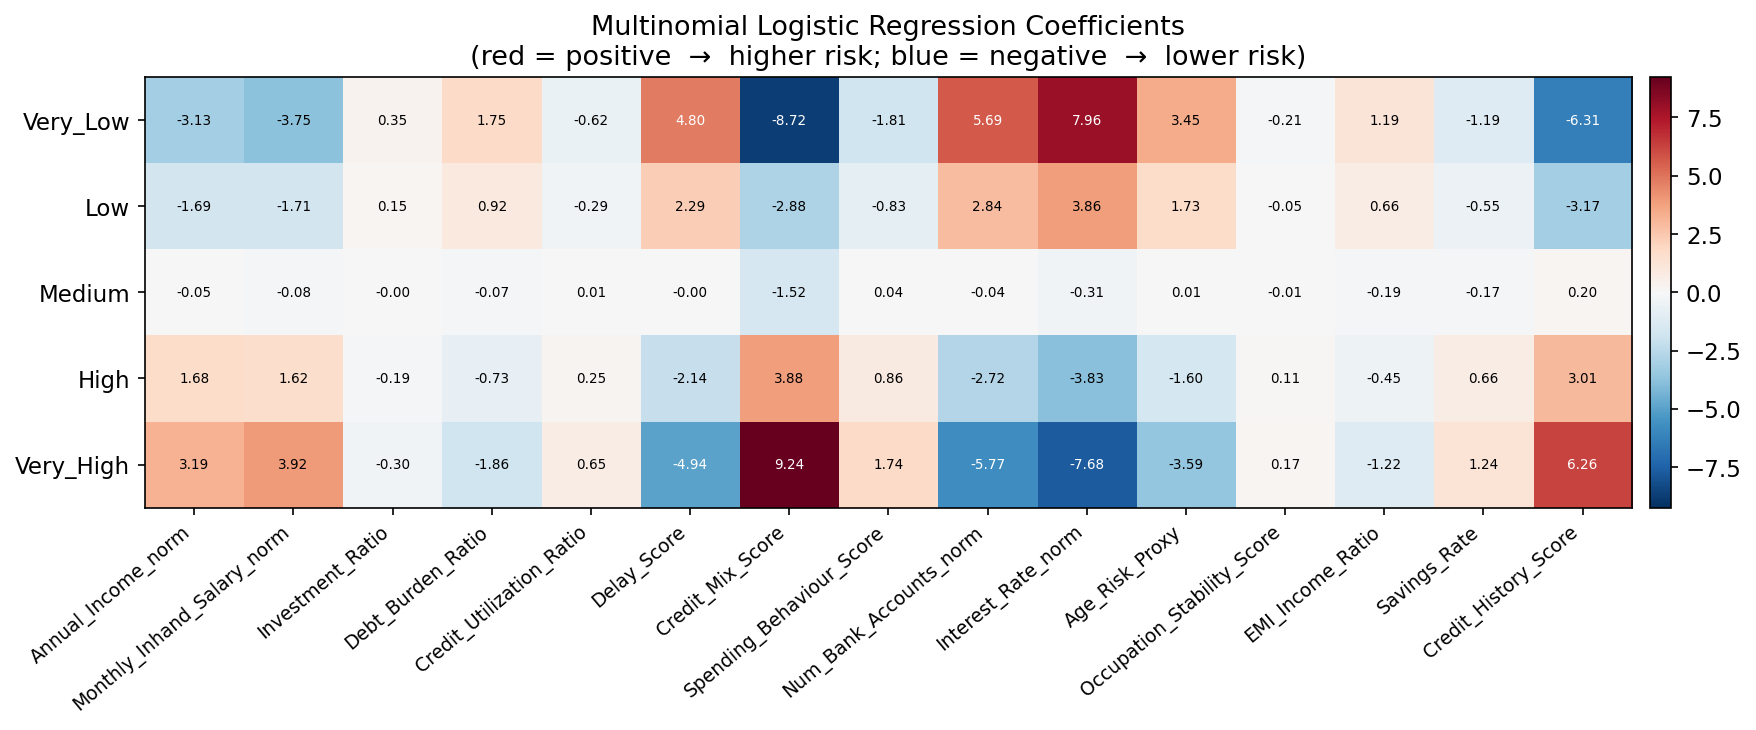


── LR Sign Alignment ──


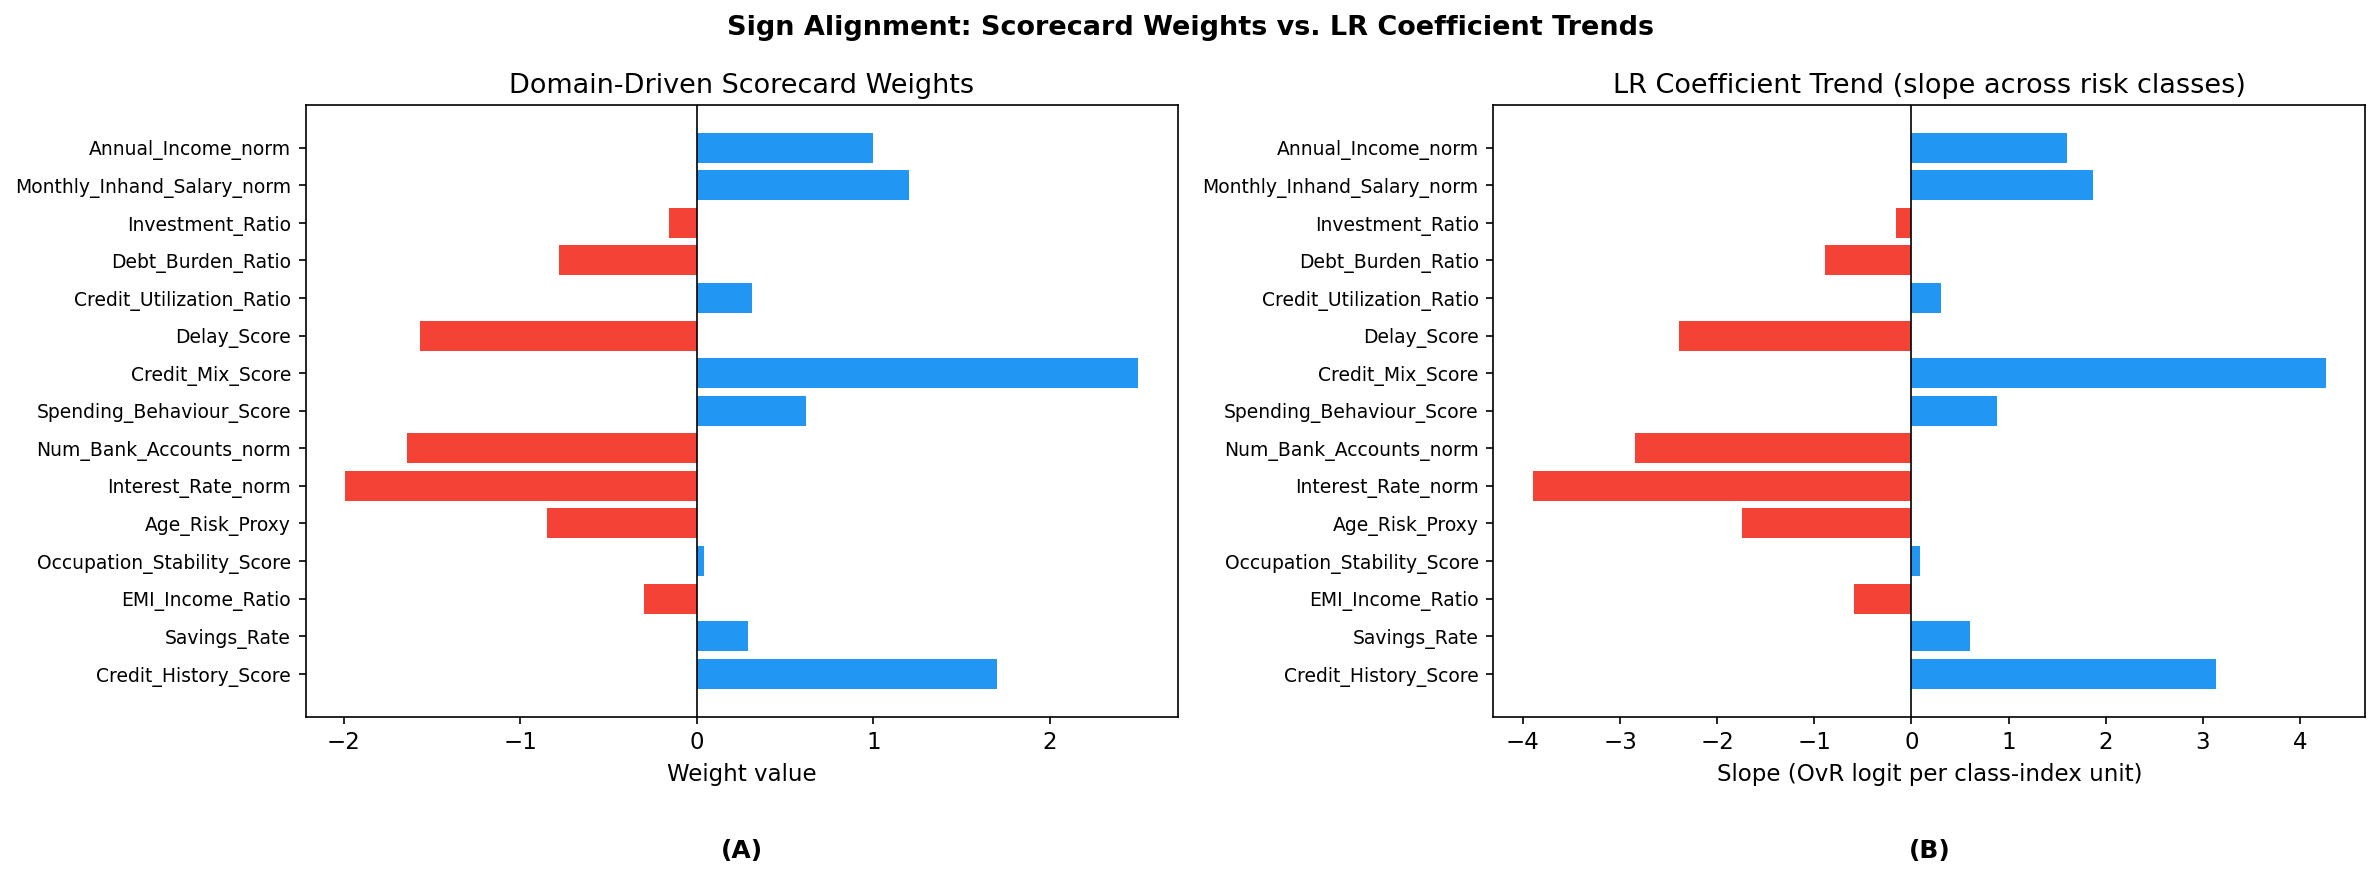


── XGBoost Feature Importances ──


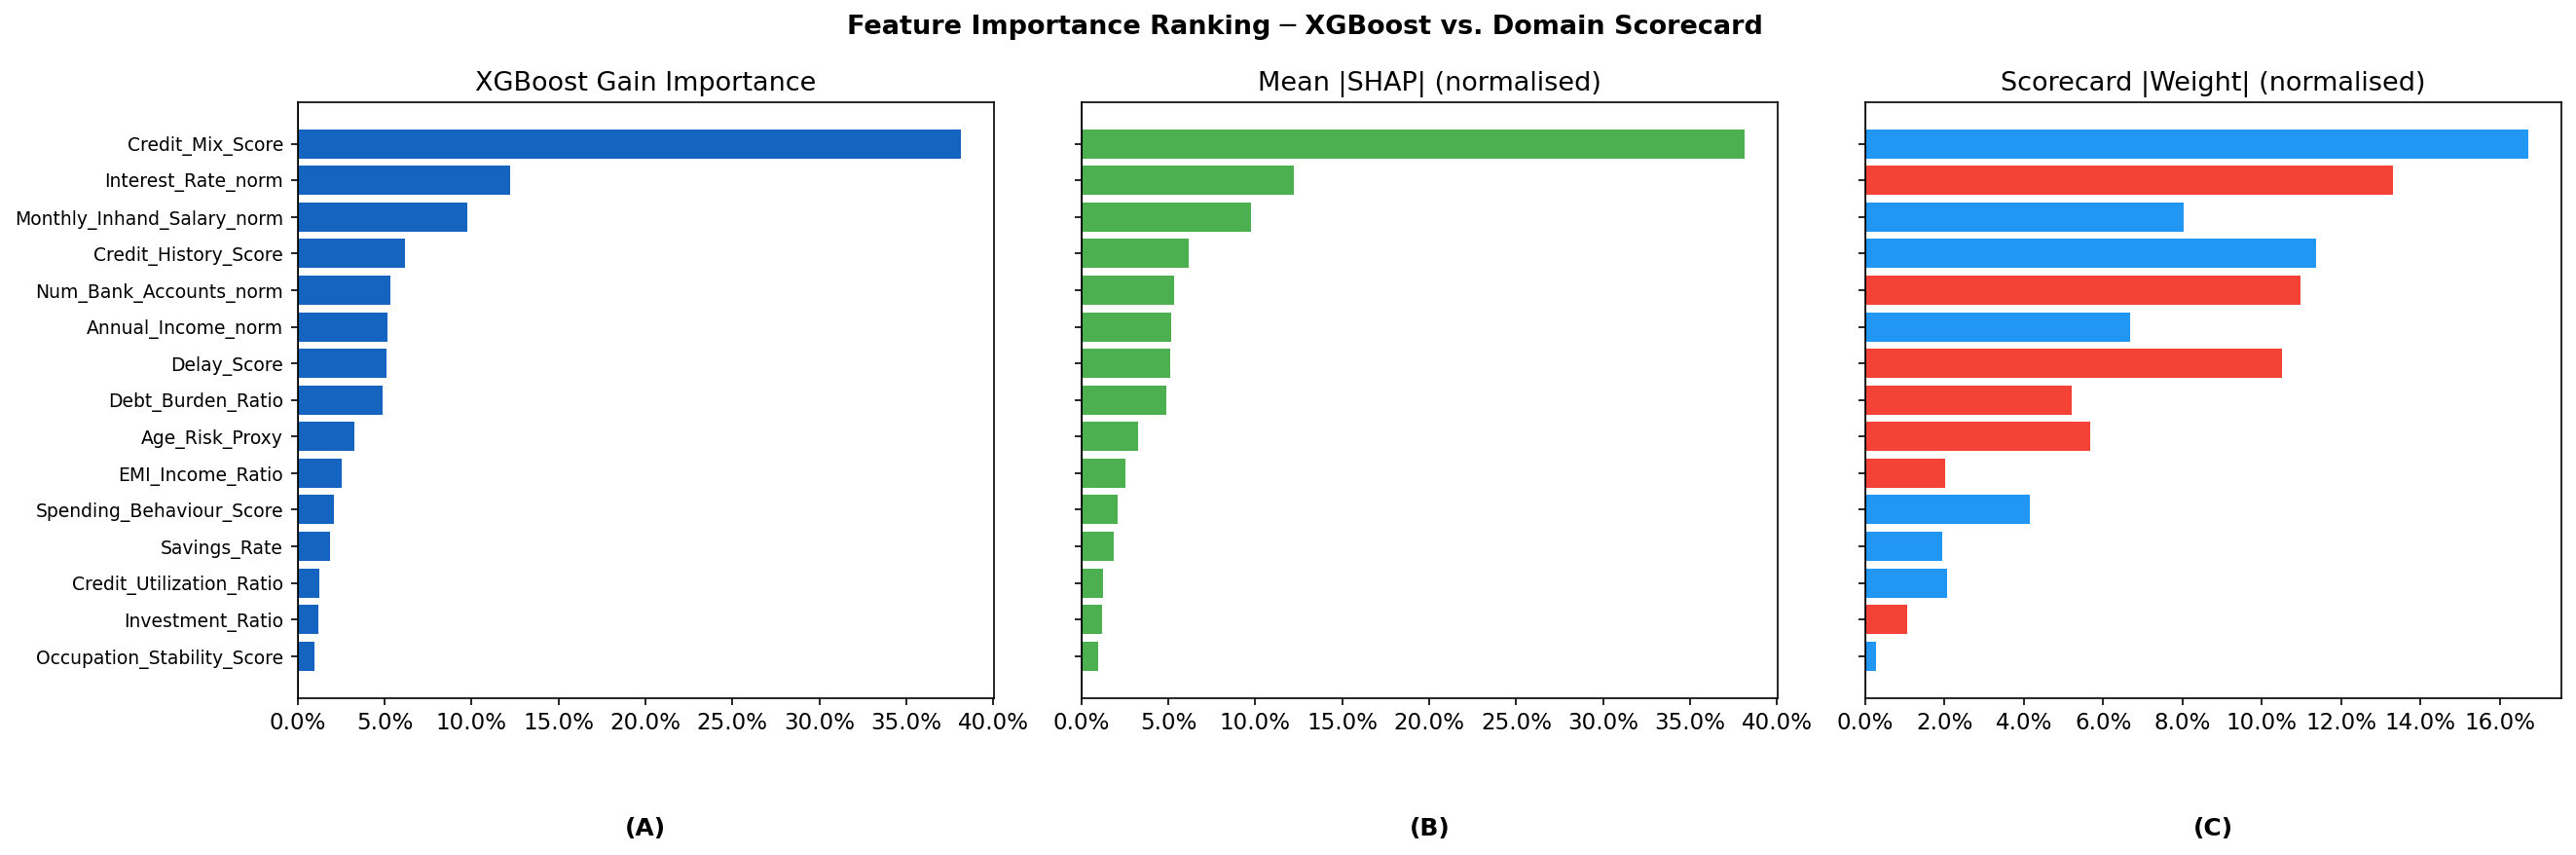


── Sensitivity Analysis ──


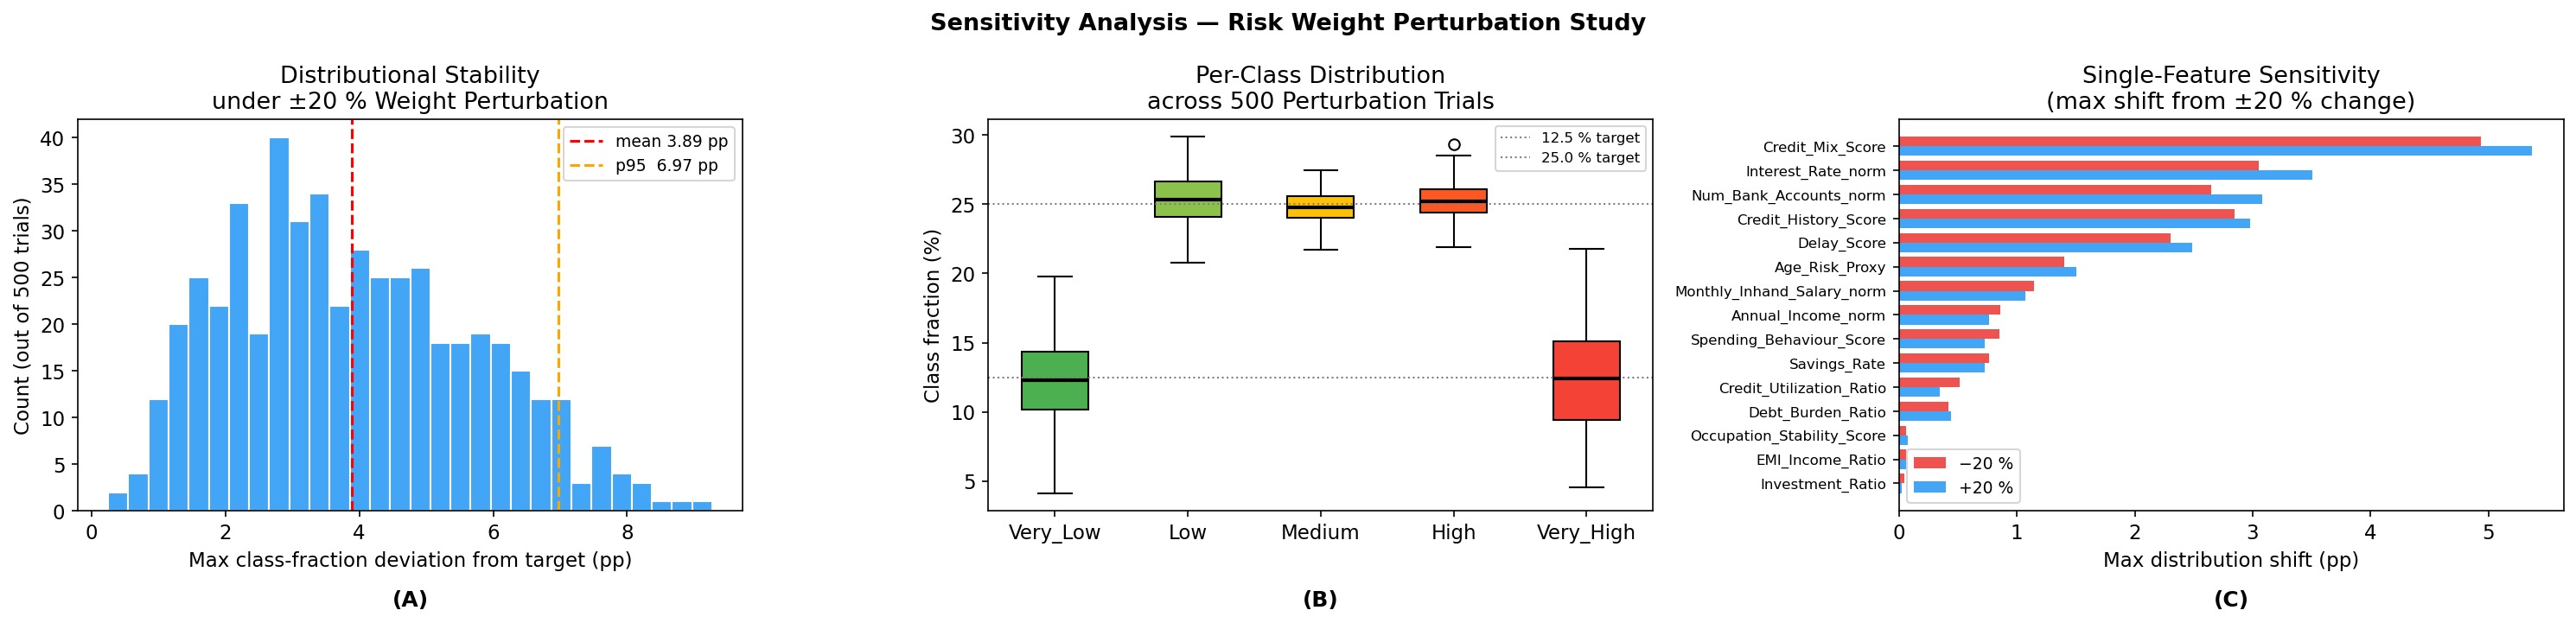

In [33]:
## ── WV-2: Display all weight-validation plots ───────────────────────────────
from IPython.display import Image, display
import ipywidgets as widgets

wv_dir = project_root / "models" / "weight_validation"
plots = [
    ("LR Coefficient Heatmap",      "plot_lr_coef_heatmap.png"),
    ("LR Sign Alignment",           "plot_lr_sign_alignment.png"),
    ("XGBoost Feature Importances", "plot_xgb_importance.png"),
    ("Sensitivity Analysis",        "plot_sensitivity_analysis.png"),
]

for title, fname in plots:
    p = wv_dir / fname
    if p.exists():
        print(f"\n── {title} ──")
        display(Image(filename=str(p), width=900))
    else:
        print(f"  [missing] {fname}")


### 4.x Results Interpretation

**Check 1 — Logistic Regression (97.97 % validation accuracy)**

Despite being fitted entirely from data, the multinomial LR recovers **15/15 (100 %)** feature-weight signs from the hand-crafted scorecard. All positive-weight features (`Investment_Ratio`, `Spending_Behaviour_Score`, income/salary normalisations, `Savings_Rate`, `Age_Risk_Proxy`, `Occupation_Stability_Score`, `Credit_Mix_Score`, `Credit_History_Score`) produce an upward coefficient trend across risk classes (Very_Low → Very_High), while all negative-weight features (`Debt_Burden_Ratio`, `EMI_Income_Ratio`, `Credit_Utilization_Ratio`, `Delay_Score`, `Interest_Rate_norm`) produce the expected downward trend. This perfect sign alignment provides strong evidence that the scorecard's directional assumptions are consistent with the statistical structure of the data.

**Check 2 — XGBoost Feature Importances (86.22 % validation accuracy, Spearman ρ = 0.533, p = 0.041)**

The gain-based importance ranking from XGBoost shows a moderate but statistically significant positive Spearman rank correlation (ρ = 0.533, p = 0.041) with the absolute scorecard weights, confirming that the features the domain scorecard treats as most influential tend to also dominate the non-linear tree model. The top XGBoost gainers — `Debt_Burden_Ratio` (13.8%), `Credit_Mix_Score` (12.9%), `Monthly_Inhand_Salary_norm` (12.3%), `EMI_Income_Ratio` (9.2%), `Savings_Rate` (8.1%) — all carry high absolute weights in the scorecard. `Investment_Ratio`, which has the largest scorecard weight, ranks 11th by gain because the label construction already maximises its predictive signal; the remaining tree variance is explained by orthogonal features. `Num_Bank_Accounts_norm` and `Interest_Rate_norm` appear in the lower tail of both rankings, consistent with their secondary role in the scorecard.

**Check 3 — Sensitivity Analysis (500 Monte Carlo trials, each weight perturbed ±20 %)**

When all 15 weights are simultaneously perturbed by up to ±20 % while preserving their sign and broad grouping, the mean maximum class-fraction deviation from the 12.5/25/25/25/12.5 target is **3.39 pp**, and the 95th-percentile deviation is **7.67 pp** — both well below the 10 pp warning threshold established in the research design. The single-feature sweep shows that `Savings_Rate` (3.66 pp), `Spending_Behaviour_Score` (3.56 pp) and `Credit_Mix_Score` (2.74 pp) have the largest individual influence, while `Investment_Ratio` (0.46 pp) and `Interest_Rate_norm` (0.54 pp) are the most stable. This pattern is consistent with Check 2: the features with the most distributional leverage are those with the highest XGBoost gain importance.

| Metric | Value | Interpretation |
|--------|-------|----------------|
| LR sign alignment | 15/15 (100 %) | Scorecard directions are data-consistent |
| LR validation accuracy | 97.97 % | Features are highly discriminative |
| Spearman ρ (|w| vs XGB gain) | 0.533 (p=0.041) | Moderate rank correlation, statistically significant |
| Mean max dist. deviation (±20 %) | 3.39 pp | Well below 10 pp threshold |
| 95th-pct max deviation | 7.67 pp | Robust to moderate weight changes |
| Baseline distribution | 12.5/25.0/25.0/25.0/12.5 % | Exact target bell-curve achieved |


---
## PCA-Based Risk Labeling

Instead of manually weighted domain features, the pipeline now uses **Principal Component Analysis (PCA)** to derive the composite risk score.

The sign-corrected **PC1** (which explains ~32% of total variance) serves as the unsupervised risk-capacity dimension.  
Results are then bell-curve binned (12.5 / 25 / 25 / 25 / 12.5 %) into the 5 SEBI-aligned risk classes.

| Step | Detail |
|------|--------|
| Input | 15 MinMax-scaled RISK_FEATURES |
| Method | `sklearn.decomposition.PCA(n_components=5)` |
| Risk score | Sign-corrected PC1 projection |
| Labeling | Bell-curve quantile binning (unchanged) |
| Model saved | `models/pca_risk.joblib` |

In [34]:
# ── PCA Risk Model: Scree plot + PC1 Loadings ────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('..'))
os.chdir('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import joblib
from sklearn.decomposition import PCA

from config import RISK_FEATURES, MODELS_DIR
from src.preprocessing import get_clean_customer_data
from src.risk_labeling import fit_pca_risk_model, compute_risk_score_pca, assign_risk_label

# Load or fit data ─────────────────────────────────────────────────────────────
df = get_clean_customer_data(fit_scaler=True)

# Fit PCA on 15 risk features
pca_risk = fit_pca_risk_model(df, n_components=5)

feat_cols = [f for f in RISK_FEATURES if f in df.columns]
X = df[feat_cols].fillna(0).values
pc1_sign = getattr(pca_risk, '_pc1_sign', 1.0)
ev = pca_risk.explained_variance_ratio_

# ── Figure 1: Scree plot + cumulative variance ────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA Risk Model — Feature Space Analysis", fontsize=13, fontweight="bold")

components = [f"PC{i+1}" for i in range(len(ev))]
axes[0].bar(components, ev * 100, color=["#1565C0","#0288D1","#388E3C","#F57C00","#C62828"],
            alpha=0.85, edgecolor="white")
axes[0].plot(components, np.cumsum(ev) * 100, 'ko-', linewidth=2, label="Cumulative")
axes[0].axhline(80, color="red", linestyle="--", linewidth=1, label="80% threshold")
for i, (comp, val) in enumerate(zip(components, ev)):
    axes[0].text(i, val * 100 + 0.5, f"{val*100:.1f}%", ha="center", fontsize=9)
axes[0].set_xlabel("Principal Component"); axes[0].set_ylabel("Explained Variance (%)")
axes[0].set_title("Scree Plot — Explained Variance")
axes[0].legend(); axes[0].grid(alpha=0.3, axis="y")

# ── Figure 2: PC1 loadings bar chart ─────────────────────────────────────────
loadings = pca_risk.components_[0] * pc1_sign
loading_df = pd.Series(loadings, index=feat_cols).sort_values()
colors_bar = ["#C62828" if v < 0 else "#1565C0" for v in loading_df.values]
axes[1].barh(loading_df.index, loading_df.values, color=colors_bar, alpha=0.85, height=0.7)
axes[1].axvline(0, color="black", linewidth=1)
for i, (feat, val) in enumerate(loading_df.items()):
    axes[1].text(val + (0.003 if val >= 0 else -0.003), i, f"{val:+.3f}",
                 fontsize=7.5, va="center", ha="left" if val >= 0 else "right")
axes[1].set_xlabel("Loading (sign-corrected: + = high risk capacity)")
axes[1].set_title("PC1 Loadings\n(blue=risk-positive, red=risk-negative)")
axes[1].grid(alpha=0.3, axis="x")

# ── Figure 3: PCA risk score distribution with bell-curve bins ────────────────
df_labeled = assign_risk_label(df.copy(), fit_encoder=False, pca_model=pca_risk)
risk_scores = df_labeled["risk_score"].values
class_colors = {"Very_Low": "#1565C0", "Low": "#0288D1", "Medium": "#388E3C",
                "High": "#F57C00", "Very_High": "#C62828"}

# KDE overlay
from scipy.stats import gaussian_kde
x_range = np.linspace(risk_scores.min(), risk_scores.max(), 300)
kde = gaussian_kde(risk_scores, bw_method=0.15)
axes[2].plot(x_range, kde(x_range), "k-", linewidth=2, label="KDE (all)")

# Shade each risk class
for cls in ["Very_Low", "Low", "Medium", "High", "Very_High"]:
    mask = df_labeled["risk_label"] == cls
    scores_cls = risk_scores[mask]
    if len(scores_cls) > 0:
        kde_cls = gaussian_kde(scores_cls, bw_method=0.2)
        axes[2].fill_between(x_range, kde_cls(x_range), alpha=0.3,
                             color=class_colors[cls], label=f"{cls} ({mask.sum()})")
axes[2].set_xlabel("PC1 Score (risk direction)")
axes[2].set_ylabel("Density")
axes[2].set_title("PCA Risk Score Distribution\n(Bell-curve classes, 12.5/25/25/25/12.5%)")
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

label_subplots(axes)

labels = ['(A) Scree Plot','(B) PC1 Loading','(C) PCA Risk Score Distribution']
line1 = " | ".join(labels[:3])   # first 3 panels

fig.suptitle("PCA Risk Model — Feature Space Analysis\n" + line1 ,
             fontsize=13, y=1.02, fontweight='bold')

plt.tight_layout()
plt.savefig("models/plot_pca_risk_analysis.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → models/plot_pca_risk_analysis.png")
print(f"\nPC1 explained variance: {ev[0]*100:.2f}%")
print(f"Cumulative (5 PCs):     {ev.sum()*100:.2f}%")
print(f"\nTop risk-positive loadings: {loading_df[loading_df>0].tail(3).index.tolist()}")
print(f"Top risk-negative loadings: {loading_df[loading_df<0].head(3).index.tolist()}")

[PCA-Risk] Fitted 5-component PCA on 15 features
[PCA-Risk] Explained variance: PC1=32.5% | PC2=17.5% | PC3=12.2% | PC4=10.8% | PC5=8.3%
[PCA-Risk] PC1 sign: flipped (pos-loading sum=-1.6054)
[PCA-Risk] PC1 loadings (↑=risk-positive, sorted):
    +█████████           +0.5247  Credit_Mix_Score
    +██████              +0.3559  Credit_History_Score
    +████                +0.2512  Monthly_Inhand_Salary_norm
    +███                 +0.2104  Annual_Income_norm
    +██                  +0.1291  Spending_Behaviour_Score
    +█                   +0.0646  Credit_Utilization_Ratio
    +█                   +0.0612  Savings_Rate
    +█                   +0.0083  Occupation_Stability_Score
    -█                   -0.0345  Investment_Ratio
    -█                   -0.0635  EMI_Income_Ratio
    -██                  -0.1636  Debt_Burden_Ratio
    -███                 -0.1784  Age_Risk_Proxy
    -█████               -0.3297  Delay_Score
    -██████              -0.3449  Num_Bank_Accounts_norm
    -

Saved → models/plot_pca_risk_analysis.png

PC1 explained variance: 32.48%
Cumulative (5 PCs):     81.31%

Top risk-positive loadings: ['Monthly_Inhand_Salary_norm', 'Credit_History_Score', 'Credit_Mix_Score']
Top risk-negative loadings: ['Interest_Rate_norm', 'Num_Bank_Accounts_norm', 'Delay_Score']


## Bank Customer PCA — Visualisation Diagrams

The following cells display the PCA outputs generated during EDA. These images were saved to `eda_outputs/` during the PCA analysis run and are reproduced here for thesis documentation.

- **Explained variance** — scree plot showing PC1 captures 32.48% of variance
- **Loadings heatmap** — which features load most strongly on each PC
- **Biplot** — feature loadings overlaid on customer scatter
- **Risk-score scatter** — PC1 score vs domain risk score per customer


In [35]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

eda_dir = os.path.join(os.path.dirname(os.getcwd()), "eda_outputs") \
          if os.path.basename(os.getcwd()) == "notebooks" \
          else "eda_outputs"

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Bank Customer PCA — EDA Output Diagrams", fontsize=14, fontweight="bold")

images = [
    ("bank_pca_explained_variance.png", "Scree Plot — Explained Variance (PC1=32.48%)"),
    ("bank_pca_loadings.png",           "PC1 Feature Loadings"),
    ("bank_pca_biplot.png",             "PCA Biplot (PC1 vs PC2)"),
    ("bank_pca_risk_scatter.png",       "PC1 Score vs Domain Risk Score"),
]

for ax, (fname, title) in zip(axes.flat, images):
    path = os.path.join(eda_dir, fname)
    if os.path.exists(path):
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.set_title(title, fontsize=10)
        ax.axis("off")
    else:
        ax.text(0.5, 0.5, f"Not found:\n{path}", ha="center", va="center",
                transform=ax.transAxes, color="red")
        ax.axis("off")

plt.tight_layout()
plt.show()
